# Assignment 1

**Group:**

Federica Del Duchetto
0001194609
federica.delduchetto@studio.unibo.it

Liam Busnelli Urso
0001180805
liam.busnelliurso@studio.unibo.it

Chiara Sivieri
0001198267
chiara.sivieri@studio.unibo.it


# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [1]:
!pip install gensim
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 88.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import os
import re
from tensorflow.keras import layers, models
from tabulate import tabulate
import textwrap
from tensorflow.keras.preprocessing.sequence import pad_sequences
from matplotlib.patches import Patch
import itertools
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support, f1_score, accuracy_score
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [3]:

def majority(items: list[str]) -> str | None:

    if not items:
        return None
    counts: dict[str, int] = {}
    for s in items:
        counts[s] = counts.get(s, 0) + 1

    max_count = -1
    winner = None
    tie = False
    for k, v in counts.items():
        if v > max_count:
            max_count = v
            winner = k
            tie = False
        elif v == max_count:
            tie = True

    return winner if not tie else None


def map(a):
  match a:
    case '-':
      return 0
    case 'DIRECT':
      return 1
    case 'JUDGEMENTAL':
      return 2
    case 'REPORTED':
      return 3
    case _:
      return None

def map_array(array):
  a = []

  for i in array:
    a.append(map(i))

  return a


def preprocess_dataset(dataset, remove_es=True):
  labels = []

  for item in dataset['labels_task2']:
    labels.append(majority(item))
  dataset['label'] = labels
  dataset = dataset.dropna(subset=['label'])
  if remove_es:
    dataset=dataset.loc[dataset['lang']=='en']
  dataset=dataset[['id_EXIST', 'lang', 'tweet','label']]
  dataset['label']=map_array(dataset['label'])
  dataset = dataset.dropna(subset=['label'])

  return dataset

def load_preprocess(filename, remove_es=True):
  dataset = pd.read_json(filename).T
  dataset = preprocess_dataset(dataset, remove_es=remove_es)

  return dataset

In [5]:

training   = load_preprocess('training.json')
validation = load_preprocess('validation.json')
test       = load_preprocess('test.json')


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [6]:

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["                      # start of character class
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002700-\U000027BF"  # dingbats
        "\U0001F900-\U0001F9FF"  # supplemental symbols
        "\U00002600-\U000026FF"  # miscellaneous symbols
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def clean_text(text):
    text = text.lower() #lowercase to lemmatize correctly
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) #urls
    text = re.sub(r'@\w+', '', text) # tags
    text = re.sub(r'#\w+', '', text) #hashtags
    text = re.sub(r'&(?:amp|lt|gt);', '', text) #special characters
    text = re.sub(r'[^A-Za-z0-9\s.,!?\'"-]', '', text) #special characters
    text = text.replace('“', '"').replace('”', '"').replace("‘", "'").replace("’", "'") #quote characters
    text = remove_emojis(text) #emojis
    text = re.sub(r'\s+', ' ', text).strip() #extra white spaces
    return text

In [7]:
training['tweet']=training['tweet'].apply(clean_text)
validation['tweet']=validation['tweet'].apply(clean_text)
test['tweet']=test['tweet'].apply(clean_text)

In [10]:
# lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import WhitespaceTokenizer

tokenizer = WhitespaceTokenizer()

lemmatizer = WordNetLemmatizer()

def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(text: str):
    tokens = tokenizer.tokenize(text)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [11]:
training['tweet'] = [lem_text(text) for text in training['tweet']]
validation['tweet'] = [lem_text(text) for text in validation['tweet']]
test['tweet'] = [lem_text(text) for text in test['tweet']]

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [ ]:
from gensim.downloader import load


print("Loading GloVe embeddings...")

glove_model = load('glove-wiki-gigaword-100')
embedding_dim = glove_model.vector_size

glove_embeddings = {word: glove_model[word] for word in glove_model.index_to_key}

print(f"Loaded {len(glove_embeddings):,} GloVe word vectors.")


# Tokenize all training tweets
training_tokens = [tokenizer.tokenize(text) for text in training["tweet"]]

vocab_train = set(token for tokens in training_tokens for token in tokens)
print(f"Vocabulary size (train only): {len(vocab_train):,}")


# Initialize embedding matrix
# -------------------------------------------------------------
# For tokens in train set that are in GloVe -> use GloVe vector
# For tokens not in GloVe -> assign a random vector
# Then, add all remaining GloVe tokens to vocabulary

embedding_matrix = {}
oov_train_tokens = []

for token in vocab_train:
    if token in glove_embeddings:
        embedding_matrix[token] = glove_embeddings[token]
    else:
        # random vector
        embedding_matrix[token] = np.random.uniform(
            low=-0.05, high=0.05, size=(embedding_dim,)
        )
        oov_train_tokens.append(token)

print(f"Train OOV tokens: {len(oov_train_tokens):,}")

# static special embedding for OOV tokens in val/test set
UNK_TOKEN = "<UNK>"
embedding_matrix[UNK_TOKEN] = np.random.uniform(
    low=-0.05, high=0.05, size=(embedding_dim,)
)

PAD_TOKEN = "<PAD>"
embedding_matrix[PAD_TOKEN] = np.zeros((embedding_dim,))

vocab_train.update([UNK_TOKEN, PAD_TOKEN])

vocab = set([token for token in glove_embeddings])

# then, add remaining GloVe tokens
for token in [x for x in glove_embeddings if x not in embedding_matrix]:
    embedding_matrix[token] = glove_embeddings[token]
vocab.update(vocab_train)

# encode input tokens to token ids
word_to_id = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for idx, token in enumerate(sorted(vocab - {PAD_TOKEN, UNK_TOKEN}), start=2):
    word_to_id[token] = idx

vocab_size = len(word_to_id)  # Should match len(vocab)

print("len vocab == len word_to_id: ", len(vocab) == len(word_to_id))

# convert embedding_matrix to NumPy array for Keras
embedding_matrix_np = np.zeros((vocab_size, embedding_dim))
for token, idx in word_to_id.items():
    if token in embedding_matrix:
        embedding_matrix_np[idx] = embedding_matrix[token]
    # OOV/specials already handled in embedding_matrix dict

print(f"Vocab size: {vocab_size}, Embedding matrix shape: {embedding_matrix_np.shape}")


Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400,000 GloVe word vectors.
Vocabulary size (train only): 13,438
Train OOV tokens: 6,156
len vocab == len word_to_id:  True
Vocab size: 406158, Embedding matrix shape: (406158, 100)


In [13]:
def encode_dataset_to_ids(df, tokenizer, word_to_id, unk_token="<UNK>", max_len=None):
    """
    Convert a DataFrame of tweets into padded sequences of token IDs.

    Args:
        df: pandas DataFrame with a column 'tweet'
        tokenizer: WhitespaceTokenizer
        word_to_id: dict mapping token -> ID
        unk_token: token for unknown words
        max_len: optional fixed max length (if None, auto-detected)

    Returns:
        A 2D NumPy array of shape (num_tweets, max_seq_len) with token IDs
    """
    all_ids = []
    for text in df['tweet']:
        tokens = tokenizer.tokenize(text)
        ids = [word_to_id.get(t, word_to_id[unk_token]) for t in tokens]
        all_ids.append(ids)

    # Determine max sequence length
    if max_len is None:
        max_len = max(len(seq) for seq in all_ids) if all_ids else 0

    # Pad shorter sequences with <PAD> ID (0)
    padded = pad_sequences(
        all_ids, maxlen=max_len, dtype='int32', padding='post', value=word_to_id[PAD_TOKEN]
    )
    return padded

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [14]:
max_seq_len = max(len(tokenizer.tokenize(text)) for text in training['tweet'])
hidden_units = 256  # Size of LSTM hidden layer

num_classes = len(set(training['label']))
class_names=['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']


X_train = encode_dataset_to_ids(training, tokenizer, word_to_id, max_len=max_seq_len)
y_train = np.array(training['label'])

X_val = encode_dataset_to_ids(validation, tokenizer, word_to_id, max_len=max_seq_len)
y_val = np.array(validation['label'])

X_test = encode_dataset_to_ids(test, tokenizer, word_to_id, max_len=max_seq_len)
y_test = np.array(test['label'])


In [15]:
# baseline model: Embedding Layer + Bidirectional LSTM + Dense output
def build_baseline_model(vocab_size, embedding_dim, embedding_matrix_np, hidden_units, num_classes, max_seq_len, trainable_emb=True):
    model = models.Sequential([
        layers.Input(shape=(max_seq_len,)),  # Input: sequences of token IDs
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix_np],
            mask_zero=True,  # Masks <PAD> tokens (ID 0)
            trainable=trainable_emb,
            name='embedding_layer'
        ),
        layers.Bidirectional(layers.LSTM(hidden_units, return_sequences=False)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



# Build model
baseline_model = build_baseline_model(vocab_size, embedding_dim, embedding_matrix_np, hidden_units, num_classes, max_seq_len)
baseline_model.summary()

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 62, 100)        │    40,615,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 512)            │       731,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,348,988 (157.73 MB)

 Trainable params: 41,348,988 (157.73 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def build_stacked_model(vocab_size, embedding_dim, embedding_matrix_np, hidden_units, num_classes, max_seq_len, trainable_emb=True):
    model = models.Sequential([
        layers.Input(shape=(max_seq_len,)),  # Input: sequences of token IDs
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix_np],
            mask_zero=True,  # Masks <PAD> tokens (ID 0)
            trainable=trainable_emb,
            name='embedding_layer'
        ),
        layers.Bidirectional(layers.LSTM(hidden_units, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(hidden_units, return_sequences=False)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


stacked_model = build_stacked_model(vocab_size, embedding_dim, embedding_matrix_np, hidden_units, num_classes, max_seq_len)
stacked_model.summary()

stacked_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 62, 100)        │    40,615,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 62, 512)        │       731,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,923,900 (163.74 MB)

 Trainable params: 42,923,900 (163.74 MB)

 Non-trainable params: 0 (0.00 B)

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation set.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

## Training function

Computes and record validation metrics across multiple random seeds and return per-seed summaries for comparison and plots.




In [17]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


class ValidationMetricsCallback(tf.keras.callbacks.Callback):
    """
    Compute per-epoch validation metrics and write them in logs.
    Adds keys:
      - 'val_macro_f1', 'val_precision', 'val_recall', 'val_accuracy' (already present)
      - 'val_weighted_f1' (weighted by support)
      - 'val_f1_class_0' ... 'val_f1_class_{num_classes-1}'
    """
    def __init__(self, validation_data, num_classes=None):
        super().__init__()
        self.X_val, self.y_val = validation_data
        # infer or use provided num_classes
        if num_classes is None:
            self.num_classes = int(np.max(self.y_val)) + 1
        else:
            self.num_classes = int(num_classes)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        preds_proba = self.model.predict(self.X_val, verbose=0)
        preds = np.argmax(preds_proba, axis=1)

        # Macro metrics
        logs['val_macro_f1'] = float(f1_score(self.y_val, preds, average='macro', zero_division=0))
        logs['val_precision'] = float(precision_score(self.y_val, preds, average='macro', zero_division=0))
        logs['val_recall'] = float(recall_score(self.y_val, preds, average='macro', zero_division=0))
        logs['val_accuracy'] = float(accuracy_score(self.y_val, preds))
        logs['val_weighted_f1'] = float(f1_score(self.y_val, preds, average='weighted', zero_division=0))

        # Per-class F1: make sure we always write one scalar per class index (0..num_classes-1)
        per_class_f1 = f1_score(self.y_val, preds, average=None, zero_division=0)
        for i in range(self.num_classes):
            # if this class is not present in per_class_f1 result, default to 0.0
            val = float(per_class_f1[i]) if i < len(per_class_f1) else 0.0
            logs[f'val_f1_class_{i}'] = val

        #print(f" - val_macro_f1: {val_f1:.4f} | val_precision: {val_prec:.4f} | val_recall: {val_rec:.4f} | val_acc: {val_acc:.4f}")

metrics_callback = ValidationMetricsCallback(validation_data=(X_val, y_val))



def train_with_seeds(
    build_model_fn,
    model_type,
    X_train, y_train,
    X_val, y_val,
    seeds,
    epochs=10,
    batch_size=32,
    callbacks_list=None,
    verbose=1,
    num_classes=4,
):
    """
    Train a model with multiple seeds and return the best (val_macro_f1) + all histories.

    Args:
        build_model_fn: function () -> compiled model (called for each seed)
        model_type: 'baseline' | 'stacked'
        X_train, y_train: training set
        X_val, y_val: validation set
        seeds: list of int (random seeds)
        epochs, batch_size: training parameters
        callbacks_list: list of Keras callbacks (should include ValidationMetricsCallback)
        verbose: 0|1|2
        num_classes: number of output classes

    Returns:
        best_model: model with best val_macro_f1 across all seeds/epochs
        all_histories: list of dict (Keras history.history + 'confusion_matrix_best') for each seed
        best_seed: int, seed of the best model
        best_epoch: int, epoch of the best model
    """
    import os

    all_histories = []
    best_f1 = -1.0
    best_model = None
    best_seed = None
    best_epoch = None

    for seed in seeds:
        # set reproducible seeds
        np.random.seed(seed)
        tf.random.set_seed(seed)

        # build model
        model = build_model_fn(model_type)

        # model checkpoint on val_macro_f1
        checkpoint_path = f"best_model_{model_type}_seed_{seed}.keras"
        checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_macro_f1',
            mode='max',
            save_best_only=True,
            verbose=0,
            save_weights_only=False
        )

        # ensure validation callback(s) go before ModelCheckpoint
        cbs = []
        if callbacks_list:
            cbs.extend(callbacks_list)
        cbs.append(checkpoint_cb)

        # fit
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=cbs,
            verbose=verbose
        )

        # determine epochs length from history
        epochs_len = len(history.history.get('val_macro_f1', [])) or epochs

        # detect whether per-epoch per-class f1 was written by callback
        per_class_keys = [f'val_f1_class_{i}' for i in range(num_classes)]
        per_class_series_present = all(k in history.history for k in per_class_keys)

        # if per-epoch per-class series are missing, create placeholders for them
        if not per_class_series_present:
            for i in range(num_classes):
                history.history[f'val_f1_class_{i}'] = [0.0] * epochs_len

        # must have val_macro_f1 to determine best epoch
        if 'val_macro_f1' not in history.history:
            raise ValueError("val_macro_f1 not present in history; ensure ValidationMetricsCallback is passed")

        # determine best epoch by val_macro_f1
        val_f1s = history.history['val_macro_f1']
        seed_best_epoch = int(np.argmax(val_f1s))
        seed_best_f1 = float(val_f1s[seed_best_epoch])

        # fallback: if callback didn't compute per-epoch per-class, compute final epoch per-class now
        if not per_class_series_present:
            try:
                y_pred_final = np.argmax(model.predict(X_val, verbose=0), axis=1)
                f1_per_class_final = f1_score(y_val, y_pred_final, average=None, zero_division=0)
                if len(f1_per_class_final) < num_classes:
                    f1_per_class_final = np.pad(f1_per_class_final, (0, num_classes - len(f1_per_class_final)))
                for i in range(num_classes):
                    history.history[f'val_f1_class_{i}'][-1] = float(f1_per_class_final[i])
            except Exception as e:
                if verbose:
                    print(f"Warning: Could not compute final per-class F1 for seed {seed}: {e}")

        # compute per-class F1 and confusion matrix for the BEST checkpoint model, store per-epoch best values
        confusion_matrix_best = None
        try:
            if not os.path.exists(checkpoint_path):
                raise FileNotFoundError(f"Checkpoint file {checkpoint_path} not found")
            model_best = tf.keras.models.load_model(checkpoint_path)
            y_pred_best = np.argmax(model_best.predict(X_val, verbose=0), axis=1)
            f1_per_class_best = f1_score(y_val, y_pred_best, average=None, zero_division=0)
            if len(f1_per_class_best) < num_classes:
                f1_per_class_best = np.pad(f1_per_class_best, (0, num_classes - len(f1_per_class_best)))
            confusion_matrix_best = confusion_matrix(y_val, y_pred_best, labels=list(range(num_classes)))

            # store best epoch values in the per-epoch series (overwrite placeholder or recorded value)
            for i in range(num_classes):
                history.history[f'val_f1_class_{i}'][seed_best_epoch] = float(f1_per_class_best[i])
        except Exception as e:
            if verbose:
                print(f"Warning: Could not load best model or compute best per-class F1 for seed {seed}: {e}")
            confusion_matrix_best = np.zeros((num_classes, num_classes), dtype=int)

        # store confusion matrix in history
        history.history['confusion_matrix_best'] = confusion_matrix_best

        # append history
        all_histories.append(history.history)

        print(f"Seed {seed}: best val_macro_f1={seed_best_f1:.4f} at epoch {seed_best_epoch+1}")


        if verbose:
            print(f"Seed {seed}: best val_macro_f1={seed_best_f1:.4f} at epoch {seed_best_epoch+1}")

        # update overall best model/seed/epoch
        if seed_best_f1 > best_f1:
            best_f1 = seed_best_f1
            best_seed = seed
            best_epoch = seed_best_epoch
            try:
                best_model = tf.keras.models.load_model(checkpoint_path)
            except Exception as e:
                if verbose:
                    print(f"Warning: Could not load best model checkpoint for seed {seed}: {e}")
                best_model = model  # fallback

    print(f"Best overall: seed={best_seed}, epoch={best_epoch+1}, val_macro_f1={best_f1:.4f}")
    return best_model, all_histories, best_seed, best_epoch


## Plot functions

All plot and utility functions contained in modules have been moved in this cell for assignment submission. No code gets executed here.

**You can collapse this.**

In [ ]:



def plot_histories_with_stats(
    all_histories,
    metrics=['accuracy', 'loss', 'val_accuracy', 'val_loss', 'val_macro_f1', 'val_precision', 'val_recall', 'val_weighted_f1'],
    y_val=None,
    big_title='',
    cm_title='',
    figsize=(15, 10),
    save_path=None
):
    """
    Plot learning curves with mean ± std overlay (except for Loss plot).
    Loss and val_loss in the same plot (dashed for train, solid for val).
    Accuracy and val_accuracy in the same plot (dashed for train, solid for val).

    Args:
        all_histories: list of dict (from train_with_seeds)
        metrics: list of metric names to plot
        y_val: validation labels (optional)
        big_title: main title for the figure
        cm_title: title used when printing confusion-matrix statistics
        figsize: tuple (width, height)
        save_path: str, path to save figure (optional)

    Notes:
        - This function assumes that if 'val_weighted_f1' is available it is already present
          in all_histories (computed during training). If not present, a zero-series is
          inserted so the plot shows 0 for weighted-F1.
    """

    if not all_histories:
        raise ValueError("No histories provided in all_histories")

    # Minimal, publication-friendly palette
    nice_colors = [
        '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860',
        '#DAA520', '#8C8C8C', '#7F7F7F', '#AED6F1', '#AF7AC5', '#A3E4D7'
    ]

    nice_colors_tab = [
    '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78',
    '#2ca02c', '#98df8a', '#d62728', '#ff9896',
    '#9467bd', '#c5b0d5', '#8c564b', '#c49c94'
    ]
    colorblind_friendly = [
    '#000000', '#E69F00', '#56B4E9', '#009E73',
    '#F0E442', '#0072B2', '#D55E00', '#CC79A7',
    '#88CCEE', '#44AA99', '#332288', '#117733'
    ]
    muted_12 = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52',
    '#8172B2', '#937860', '#DAA520', '#8C8C8C',
    '#7F7F7F', '#AED6F1', '#AF7AC5', '#A3E4D7'
    ]

    nice_colors = muted_12

    mean_color = '#000000'
    std_color = '#808080'

    # Group metrics and select which to plot
    grouped_metrics = {
        'Loss': ('loss', 'val_loss'),
        'Accuracy': ('accuracy', 'val_accuracy'),
        'Macro F1': ('val_macro_f1',),
        'Weighted F1': ('val_weighted_f1',),
        'Precision': ('val_precision',),
        'Recall': ('val_recall',)
    }

    plots_needed = []
    for title, metric_pair in grouped_metrics.items():
        if any(m in metrics for m in metric_pair):
            plots_needed.append((title, metric_pair))

    n_plots = len(plots_needed)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_plots > 1 else [axes]

    if big_title:
        fig.suptitle(big_title, fontsize=16, fontweight='bold')
        fig.subplots_adjust(top=0.92)

    # Ensure val_weighted_f1 series exists in each history. If not, create zero-series
    for hist in all_histories:
        if 'val_weighted_f1' not in hist:
            # determine a sensible epoch length
            if 'val_macro_f1' in hist and isinstance(hist['val_macro_f1'], list):
                length = len(hist['val_macro_f1'])
            else:
                # fallback to any list metric
                list_metrics = [v for v in hist.values() if isinstance(v, list) and v]
                length = len(list_metrics[0]) if list_metrics else 1
            hist['val_weighted_f1'] = [0.0] * length

    # Prepare stats (mean ± std) for validation metrics across seeds
    stats_dict = {}
    for title, metric_pair in plots_needed:
        for metric in metric_pair:
            if metric.startswith('val_'):
                values = [hist[metric] for hist in all_histories if metric in hist]
                if values:
                    min_epochs = min(len(v) for v in values)
                    arr = np.array([v[:min_epochs] for v in values], dtype=float)
                    stats_dict[metric] = {
                        'mean': arr.mean(axis=0),
                        'std': arr.std(axis=0),
                        'epochs': range(1, arr.shape[1] + 1)
                    }

    # Plot metrics
    for idx, (title, metric_pair) in enumerate(plots_needed):
        ax = axes[idx]
        show_mean = title != 'Loss'  # do not show mean/std for loss

        for seed_idx, hist in enumerate(all_histories):
            color_idx = seed_idx % len(nice_colors)
            for metric in metric_pair:
                if metric not in hist:
                    continue
                epochs_range = range(1, len(hist[metric]) + 1)
                if metric.startswith('val_'):
                    linestyle = '-'
                    label = f'Val Seed {seed_idx + 1}'
                else:
                    linestyle = '--'
                    label = f'Train Seed {seed_idx + 1}'
                ax.plot(
                    epochs_range,
                    hist[metric],
                    label=label,
                    color=nice_colors[color_idx],
                    linestyle=linestyle,
                    alpha=0.6,
                    linewidth=1.2
                )

        # Overlay mean ± std for validation metrics (except Loss)
        if show_mean:
            for metric in metric_pair:
                if metric.startswith('val_') and metric in stats_dict:
                    s = stats_dict[metric]
                    ax.plot(s['epochs'], s['mean'], color=mean_color, linewidth=1.5, label='Mean', zorder=100)
                    ax.fill_between(s['epochs'], s['mean'] - s['std'], s['mean'] + s['std'],
                                    color=std_color, alpha=0.10, label='±1 Std', zorder=99)

        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(title, fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='best')
        ax.grid(True, alpha=0.3, linestyle=':')

    # Remove unused axes
    for idx in range(n_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # confusion matrix and stats printing
    class_names = ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']
    avg_cm = plot_average_confusion_matrix(
        all_histories,
        class_names=class_names,
        cmap='Reds',
        big_title=cm_title,
        figsize=(6, 4),
        save_path='confusion_matrix.png',
        normalize='percentage'
    )

    _print_statistics_tables(all_histories, stats_dict, y_val)


def _print_statistics_tables(all_histories, stats_dict, y_val=None):
    """
    Print formatted statistics tables for final and best epochs.

    Args:
        all_histories: list of training histories
        stats_dict: dict with computed statistics
    """

    # Compute final epoch stats
    final_stats = _compute_epoch_stats(all_histories, stats_dict, epoch_type='final', y_val=y_val)

    # Compute best epoch stats (per val_macro_f1)
    best_stats = _compute_epoch_stats(all_histories, stats_dict, epoch_type='best', y_val=y_val)

    # # Print Final Epoch Table
    # tolta perchè inutile alla fine
    # print("\n Final epoch statistics")
    # print("-" * 80)
    # _print_stats_table(final_stats)

    # Print Best Epoch Table
    print("\n Best epoch statistics (based on macro f1 score on validation set)")
    print("-" * 80)
    _print_stats_table(best_stats)
    print("\n")


def _compute_epoch_stats(all_histories, stats_dict, epoch_type='final', y_val=None):
    """
    Compute statistics for a specific epoch type.

    Args:
        all_histories: list of training histories
        stats_dict: dict with computed statistics
        epoch_type: 'final' or 'best'
        y_val: validation labels (needed for weighted F1 calculation)

    Returns:
        dict with statistics
    """
    metrics_base = ['val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_macro_f1']

    stats = {}

    # Compute base metrics
    for metric in metrics_base:
        values = []
        for hist in all_histories:
            if metric in hist:
                if epoch_type == 'final':
                    values.append(hist[metric][-1])
                else:  # best
                    best_idx = int(np.argmax(hist['val_macro_f1']))
                    values.append(hist[metric][best_idx])

        if values:
            stats[metric] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }

    # Compute per-class F1 metrics
    num_classes = 4  # Can be made configurable
    for class_idx in range(num_classes):
        values = []

        for hist in all_histories:
            if epoch_type == 'final':
                # Look for final epoch F1
                metric_key = f'val_f1_class_{class_idx}'
                if metric_key in hist:
                    # Get last non-zero value (final epoch)
                    final_value = hist[metric_key][-1]
                    values.append(final_value)
            else:  # best
                # Look for best epoch F1
                metric_key = f'val_f1_class_{class_idx}'
                if metric_key in hist:
                    best_idx = int(np.argmax(hist['val_macro_f1']))
                    best_value = hist[metric_key][best_idx]
                    values.append(best_value)

        if values:
            stats[f'val_f1_class_{class_idx}'] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }

    # Compute weighted F1 (weighted by class support)
    if y_val is not None:
        weighted_f1_values = []

        # Calculate class weights from validation set
        unique_classes, class_counts = np.unique(y_val, return_counts=True)
        total_samples = len(y_val)
        class_weights = {cls: count / total_samples for cls, count in zip(unique_classes, class_counts)}

        # For each history, compute weighted F1
        for hist in all_histories:
            weighted_sum = 0.0
            weight_sum = 0.0

            for class_idx in range(num_classes):
                metric_key = f'val_f1_class_{class_idx}'
                if metric_key in hist:
                    if epoch_type == 'final':
                        f1_value = hist[metric_key][-1]
                    else:  # best
                        best_idx = int(np.argmax(hist['val_macro_f1']))
                        f1_value = hist[metric_key][best_idx]

                    # Get weight for this class (0 if class not in validation set)
                    weight = class_weights.get(class_idx, 0.0)
                    weighted_sum += f1_value * weight
                    weight_sum += weight

            # Normalize by total weight
            if weight_sum > 0:
                weighted_f1_values.append(weighted_sum / weight_sum)

        if weighted_f1_values:
            stats['val_weighted_f1'] = {
                'mean': np.mean(weighted_f1_values),
                'std': np.std(weighted_f1_values)
            }

    return stats


def _print_stats_table(stats, y_val=None):
    """
    Print a formatted statistics table using tabulate.

    Args:
        stats: dict with statistics {metric: {'mean': float, 'std': float}}
        y_val: validation labels (for displaying class distribution)
    """
    # Base metrics table
    base_metrics = ['val_loss', 'val_accuracy', 'val_precision', 'val_recall']
    base_data = []
    for metric in base_metrics:
        if metric in stats:
            metric_name = metric.replace('val_', '').replace('_', ' ').title()
            mean_val = stats[metric]['mean']
            std_val = stats[metric]['std']
            base_data.append([metric_name, f"{mean_val:.4f} ± {std_val:.4f}"])

    print(tabulate(base_data, headers=['Metric', 'Mean ± Std'], tablefmt='rounded_outline'))

    # Calculate class distribution if y_val provided
    class_distribution = {}
    if y_val is not None:
        unique_classes, class_counts = np.unique(y_val, return_counts=True)
        total_samples = len(y_val)
        class_distribution = {cls: (count, count / total_samples * 100)
                            for cls, count in zip(unique_classes, class_counts)}

    # F1 scores table (separated)
    print("\n  F1 Scores:")
    f1_metrics = ['val_macro_f1', 'val_weighted_f1', 'val_f1_class_0', 'val_f1_class_1',
                  'val_f1_class_2', 'val_f1_class_3']
    f1_data = []
    class_names = ['Macro F1', 'Weighted F1', 'Class 0 (-)', 'Class 1 (DIRECT)',
                   'Class 2 (JUDGEMENTAL)', 'Class 3 (REPORTED)']

    for i, metric in enumerate(f1_metrics):
        if metric in stats:
            mean_val = stats[metric]['mean']
            std_val = stats[metric]['std']

            # Add class distribution info for per-class metrics
            if metric.startswith('val_f1_class_'):
                class_idx = int(metric.split('_')[-1])
                if class_idx in class_distribution:
                    count, percentage = class_distribution[class_idx]
                    f1_data.append([
                        f"{class_names[i]} (n={count}, {percentage:.1f}%)",
                        f"{mean_val:.4f} ± {std_val:.4f}"
                    ])
                else:
                    f1_data.append([class_names[i], f"{mean_val:.4f} ± {std_val:.4f}"])
            else:
                f1_data.append([class_names[i], f"{mean_val:.4f} ± {std_val:.4f}"])

    print(tabulate(f1_data, headers=['Category', 'F1 Score'], tablefmt='rounded_outline'))


def plot_average_confusion_matrix(
    all_histories,
    class_names=None,
    big_title='',
    figsize=(10, 8),
    save_path=None,
    cmap='Blues',
    normalize='percentage',
    verbose=False,
    show_plot=True
):
    """
    Plot the average confusion matrix across all seeds (best epoch for each seed).

    Args:
        all_histories: list of dict from train_with_seeds (must contain 'confusion_matrix_best')
        class_names: list of str, names for each class (optional)
        figsize: tuple, figure size
        save_path: str, path to save figure (optional)
        cmap: str, colormap for heatmap
        normalize: str, 'percentage' (row-wise %), 'true' (normalize by true class), or None

    Returns:
        avg_confusion_matrix: numpy array, average confusion matrix
    """
    # Extract all confusion matrices
    confusion_matrices = []
    for hist in all_histories:
        if 'confusion_matrix_best' in hist and hist['confusion_matrix_best'] is not None:
            confusion_matrices.append(hist['confusion_matrix_best'])

    if not confusion_matrices:
        print("Warning: No confusion matrices found in histories")
        return None

    # Compute average confusion matrix
    avg_confusion_matrix = np.mean(confusion_matrices, axis=0)

    # Normalize if requested
    if normalize == 'percentage' or normalize == 'true':
        # Normalize by row (true class)
        row_sums = avg_confusion_matrix.sum(axis=1, keepdims=True)
        # Avoid division by zero
        row_sums[row_sums == 0] = 1
        normalized_cm = avg_confusion_matrix / row_sums * 100  # Convert to percentage
    else:
        normalized_cm = avg_confusion_matrix

    # Default class names if not provided
    if class_names is None:
        num_classes = avg_confusion_matrix.shape[0]
        class_names = [f'Class {i}' for i in range(num_classes)]

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create heatmap
    if normalize:
        sns.heatmap(
            normalized_cm / 100.0,
            annot=True,
            fmt='.1%',
            cmap=cmap,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Percentage (%)'},
            ax=ax,
            vmin=0,
            vmax=100 / 100.0 # divide by 100 to show % in annotations and keep colormap adequate
        )
        title = big_title if big_title else 'Average Confusion Matrix, Normalized by True labels (%)'
    else:
        sns.heatmap(
            normalized_cm,
            annot=True,
            fmt='.1f',
            cmap=cmap,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            ax=ax
        )
        title = big_title if big_title else 'Average Confusion Matrix (Raw Counts)'

    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    if show_plot:
      plt.show()
    else:
      plt.close(fig)

    # Print statistics
    if verbose:
      print("AVERAGE CONFUSION MATRIX STATISTICS")
      print(f"Number of seeds averaged: {len(confusion_matrices)}")
      print(f"\nAverage Confusion Matrix (raw counts):")
      print(avg_confusion_matrix)
      if normalize:
          print(f"\nNormalized Confusion Matrix (percentage by row):")
          print(normalized_cm)

    return avg_confusion_matrix


def plot_boxplot_metrics_comparison(
    histories_a,
    histories_b,
    model_labels=('Model A', 'Model B'),
    class_names=None,
    figsize=(14, 6),
    save_path=None,
    palette=None
):
    """
    Boxplot comparison of metrics measured at the best epoch (best val_macro_f1) across seeds.
    Metrics shown (per validation best epoch): Accuracy, Precision, Recall, Macro F1, Weighted F1,
    and F1 per class. Each metric is shown as paired boxplots: one box per model.

    Args:
        histories_a, histories_b: list[dict] as returned by train_with_seeds
        model_labels: tuple of two strings for legend
        class_names: optional list of class names (length == num_classes)
        figsize: figure size
        save_path: optional path to save figure
        palette: seaborn/matplotlib color palette (iterable of two colors)

    Returns:
        fig, ax, stats_dict
            fig, ax: matplotlib objects
            stats_dict: dict with per-model arrays of extracted best-epoch metrics (means/stdevs)
    """

    if palette is None:
        palette = [ '#4C72B0', '#DD8452' ]

    # Infer num_classes from keys like 'val_f1_class_{i}'
    def infer_num_classes(histories):
        pattern = re.compile(r'^val_f1_class_(\d+)$')
        max_idx = -1
        for h in histories:
            for k in h.keys():
                m = pattern.match(k)
                if m:
                    i = int(m.group(1))
                    if i > max_idx:
                        max_idx = i
        return (max_idx + 1) if max_idx >= 0 else 0

    num_classes = max(infer_num_classes(histories_a), infer_num_classes(histories_b))
    if num_classes == 0:
        raise ValueError("Could not infer number of classes from histories (no 'val_f1_class_i' keys).")

    # default class names
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    if len(class_names) != num_classes:
        raise ValueError("class_names length must match inferred num_classes")

    # helper: extract values at best epoch (argmax val_macro_f1) or last epoch fallback
    def extract_best_metrics_from_history(h):
        # determine best epoch index
        if 'val_macro_f1' in h and isinstance(h['val_macro_f1'], list) and len(h['val_macro_f1'])>0:
            best_idx = int(np.argmax(h['val_macro_f1']))
        else:
            lists = [v for v in h.values() if isinstance(v, list) and len(v)>0]
            best_idx = len(lists[0]) - 1 if lists else 0

        def get_val(key):
            # prefer validation metric 'val_{key}' names in history
            k = key if key.startswith('val_') else f'val_{key}'
            if k in h and isinstance(h[k], list) and best_idx < len(h[k]):
                return float(h[k][best_idx])
            # fallback to key without val_ if present
            if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                return float(h[key][best_idx])
            return 0.0

        accuracy = get_val('accuracy')
        precision = get_val('precision')
        recall = get_val('recall')
        macro_f1 = get_val('macro_f1') if 'val_macro_f1' not in h else float(h['val_macro_f1'][best_idx])
        # weighted f1: prefer val_weighted_f1, else try to compute using confusion_matrix_best supports or equal weights
        if 'val_weighted_f1' in h and isinstance(h['val_weighted_f1'], list) and best_idx < len(h['val_weighted_f1']):
            weighted = float(h['val_weighted_f1'][best_idx])
        else:
            # try supports from confusion_matrix_best
            supports = None
            if 'confusion_matrix_best' in h and getattr(h['confusion_matrix_best'], 'sum', None):
                cm = np.asarray(h['confusion_matrix_best'], dtype=float)
                rs = cm.sum(axis=1)
                total = rs.sum()
                if total > 0:
                    supports = rs / total
            if supports is None or len(supports) != num_classes:
                supports = np.ones(num_classes, dtype=float) / float(num_classes)
            # per-class f1 at best idx
            per_class = np.zeros(num_classes, dtype=float)
            for i in range(num_classes):
                key = f'val_f1_class_{i}'
                if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                    per_class[i] = float(h[key][best_idx])
                elif key in h and isinstance(h[key], list) and len(h[key])>0:
                    per_class[i] = float(h[key][-1])
                else:
                    per_class[i] = 0.0
            weighted = float(np.dot(per_class, supports))

        # per-class f1 vector
        per_class = np.zeros(num_classes, dtype=float)
        for i in range(num_classes):
            key = f'val_f1_class_{i}'
            if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                per_class[i] = float(h[key][best_idx])
            elif key in h and isinstance(h[key], list) and len(h[key])>0:
                per_class[i] = float(h[key][-1])
            else:
                per_class[i] = 0.0

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'macro_f1': macro_f1,
            'weighted_f1': weighted,
            'per_class': per_class
        }

    # gather metrics across seeds for a histories list
    def gather_all_metrics(histories):
        rows = []
        per_class_matrix = []
        for h in histories:
            m = extract_best_metrics_from_history(h)
            rows.append(m)
            per_class_matrix.append(m['per_class'])
        # build arrays
        return rows, np.vstack(per_class_matrix) if per_class_matrix else np.zeros((0, num_classes))

    rows_a, pc_a = gather_all_metrics(histories_a)
    rows_b, pc_b = gather_all_metrics(histories_b)

    # build tidy DataFrame suitable for seaborn boxplot: columns = Metric, Model, Value
    records = []
    # metrics order
    metric_order = ['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1'] + [f'F1: {n}' for n in class_names]

    def add_records_from_rows(rows, model_label):
        for r in rows:
            records.append({'Metric':'Accuracy', 'Model':model_label, 'Value': r['accuracy']})
            records.append({'Metric':'Precision', 'Model':model_label, 'Value': r['precision']})
            records.append({'Metric':'Recall', 'Model':model_label, 'Value': r['recall']})
            records.append({'Metric':'Macro F1', 'Model':model_label, 'Value': r['macro_f1']})
            records.append({'Metric':'Weighted F1', 'Model':model_label, 'Value': r['weighted_f1']})
            for i, cname in enumerate(class_names):
                records.append({'Metric': f'F1: {cname}', 'Model': model_label, 'Value': float(r['per_class'][i])})

    add_records_from_rows(rows_a, model_labels[0])
    add_records_from_rows(rows_b, model_labels[1])

    df = pd.DataFrame.from_records(records)
    # ensure Metric categorical ordering
    df['Metric'] = pd.Categorical(df['Metric'], categories=metric_order, ordered=True)

    # Plot
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df, x='Metric', y='Value', hue='Model', palette=palette, ax=ax)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlabel('')
    ax.set_title(f'Metric distributions on validation set at best epoch per-seed ({model_labels[0]} vs {model_labels[1]})', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    # caption below figure
    caption = (
        "Each box shows the distribution across seeds of the metric value extracted at the seed's best epoch.\n"
        "Best epoch per seed is selected as the epoch with highest validation Macro F1. "
    )
    fig.text(0.5, -0.05, caption, ha='center', fontsize=9)

    plt.legend(title='')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # prepare simple stats_dict of means/stds for programmatic use
    def summarize(rows, pc_matrix):
        arr = np.array([[r['accuracy'], r['precision'], r['recall'], r['macro_f1'], r['weighted_f1']] for r in rows], dtype=float)
        means = np.nanmean(arr, axis=0)
        stds = np.nanstd(arr, axis=0)
        per_class_means = np.nanmean(pc_matrix, axis=0) if pc_matrix.size>0 else np.zeros(num_classes)
        per_class_stds = np.nanstd(pc_matrix, axis=0) if pc_matrix.size>0 else np.zeros(num_classes)
        return {'means':means, 'stds':stds, 'per_class_means':per_class_means, 'per_class_stds':per_class_stds}

    stats = {
        model_labels[0]: summarize(rows_a, pc_a),
        model_labels[1]: summarize(rows_b, pc_b),
        'metric_order': metric_order,
        'class_names': class_names
    }

    return fig, ax, stats


def plot_avg_cm_difference(
    all_histories_1,
    all_histories_2,
    model_1_name='Baseline',
    model_2_name='Stacked',
    class_names=['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'],
    cmap='RdBu_r'
):
  baseline_avg_cm = plot_average_confusion_matrix(
      all_histories_1,
      class_names=class_names,
      cmap='Reds',
      big_title='prova baseline',
      figsize=(10, 8),
      save_path='confusion_matrix.png',
      normalize='percentage',
      show_plot=False
  )

  stacked_avg_cm = plot_average_confusion_matrix(
      all_histories_2,
      class_names=class_names,
      cmap='Reds',
      big_title='prova stacked',
      figsize=(10, 8),
      save_path='confusion_matrix.png',
      normalize='percentage',
      show_plot=False
  )

  diff = stacked_avg_cm - baseline_avg_cm

  figsize=(8,6)

  # Plot heatmap of the difference, centered at 0
  vmax = np.nanmax(np.abs(diff)) if diff.size > 0 else 1.0
  plt.figure(figsize=figsize)
  ax = sns.heatmap(
      diff,
      annot=np.array([[f"{v:.1f}%" for v in row] for row in diff]),
      fmt='',
      cmap=cmap,
      center=0.0,
      vmin=-vmax,
      vmax=vmax,
      xticklabels=class_names,
      yticklabels=class_names,
      cbar_kws={'label': f'Difference in % ({model_2_name} - {model_1_name})'}
  )
  ax.set_xlabel('Predicted class', fontsize=10)
  ax.set_ylabel('True class', fontsize=10)
  ax.set_title(f'Confusion matrix difference ({model_2_name} - {model_1_name})', fontsize=12, fontweight='bold')
  plt.tight_layout()
  plt.show()

def _is_light(hexcol):
    """
    Return True if hex color is light (use black text), False for dark (use white text).
    """
    hexcol = hexcol.lstrip('#')
    r, g, b = int(hexcol[0:2], 16), int(hexcol[2:4], 16), int(hexcol[4:6], 16)
    # perceptual luminance
    lum = 0.299*r + 0.587*g + 0.114*b
    return lum > 186


def plot_cm_difference_best_models(
    all_histories_1,
    all_histories_2,
    model_1_name='Baseline',
    model_2_name='Stacked',
    class_names=['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'],
    cmap='RdBu_r',
):
    """
    Select best seed-history (highest val_macro_f1) from each list of histories,
    extract its 'confusion_matrix_best', convert to row-percentages, compute difference
    (model_2 - model_1) in percentage points and plot the heatmap with a caption.
    Returns (cm1_pct, cm2_pct, diff, fig, ax).
    """

    def select_best_history(histories):
        """Return the history dict with the largest max(val_macro_f1)."""
        best_h = None
        best_val = -np.inf
        for h in histories:
            vals = h.get('val_macro_f1', [])
            maxv = max(vals) if len(vals) > 0 else -np.inf
            if maxv > best_val:
                best_val = maxv
                best_h = h
        return best_h

    # pick best histories
    h1 = select_best_history(all_histories_1)
    h2 = select_best_history(all_histories_2)

    # extract confusion matrices (fallback to zeros)
    C = len(class_names)
    cm1 = np.array(h1.get('confusion_matrix_best', np.zeros((C, C), dtype=float))) if h1 is not None else np.zeros((C, C), dtype=float)
    cm2 = np.array(h2.get('confusion_matrix_best', np.zeros((C, C), dtype=float))) if h2 is not None else np.zeros((C, C), dtype=float)

    # ensure correct shape
    if cm1.shape != (C, C):
        cm1 = np.reshape(cm1, (C, C)) if cm1.size == C*C else np.zeros((C, C), dtype=float)
    if cm2.shape != (C, C):
        cm2 = np.reshape(cm2, (C, C)) if cm2.size == C*C else np.zeros((C, C), dtype=float)

    # convert to row-wise percentages (handle zero rows)
    with np.errstate(divide='ignore', invalid='ignore'):
        row_sums1 = cm1.sum(axis=1, keepdims=True).astype(float)
        row_sums2 = cm2.sum(axis=1, keepdims=True).astype(float)
        row_sums1[row_sums1 == 0] = 1.0
        row_sums2[row_sums2 == 0] = 1.0
        cm1_pct = (cm1 / row_sums1) * 100.0
        cm2_pct = (cm2 / row_sums2) * 100.0

    diff = cm2_pct - cm1_pct

    # plot
    figsize = (8, 6)
    vmax = np.nanmax(np.abs(diff)) if diff.size > 0 else 1.0
    fig, ax = plt.subplots(figsize=figsize)
    annot = np.array([[f"{v:.1f}%" for v in row] for row in diff])
    sns.heatmap(
        diff,
        annot=annot,
        fmt='',
        cmap=cmap,
        center=0.0,
        vmin=-vmax,
        vmax=vmax,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': f'Difference in % ({model_2_name} - {model_1_name})'},
        ax=ax
    )
    ax.set_xlabel('Predicted class', fontsize=10)
    ax.set_ylabel('True class', fontsize=10)
    ax.set_title(f'Confusion matrix difference ({model_2_name} - {model_1_name})', fontsize=12, fontweight='bold')

    # caption below figure
    caption = (
        "Confusion matrices are taken from the best checkpoint of the best seed (highest validation Macro F1).\n"
        f"In general, a red color on the main diagonal indicates that {model_2_name} performs better than {model_1_name} on that class.\n"
        f"While a red color in other squares means that {model_2_name} confuses the corresponding classes more than {model_1_name}."
    )
    # place caption; use figure coordinates so it appears under the plot
    fig.text(0.5, -0.05, caption, ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return cm1_pct, cm2_pct, diff, fig, ax



# actually not used anymore since the one that plots every model's output is clearer
# cool palette palette=['#A3E4D7', '#EB419C', '#D7BDE2', '#8E44AD']
def plot_sentence_probability_bars(
    sentences,
    model,
    tokenizer=None,
    tokenizer_type='whitespace',  # 'whitespace' | 'hf'
    word_to_id=None,
    max_len=None,
    unk_token="<UNK>",
    pad_token="<PAD>",
    class_names=None,
    batch_size=32,
    palette=None,
    figsize=None,
    show_prob_annotations=True,
    min_annot_width=0.05,
    save_path=None,
    legend_loc='bottom'  # 'top' or 'bottom'
):
    """
    Predict class probabilities for a list of sentences with `model` and plot them as stacked horizontal bars.
    Legend with color/name for each class is drawn above or below the chart instead of text inside bars.

    Returns:
      - probs: numpy array shape (len(sentences), num_classes)
      - fig, ax: matplotlib figure & axis
    """

    # defaults
    if palette is None:
        palette = ['#7FB3D5', '#F6C9A8', '#A9D6F5', '#FFB3AB']
    if class_names is None:
        try:
            C = model.output_shape[-1]
        except Exception:
            C = len(palette)
        class_names = [str(i) for i in range(C)]
    else:
        C = len(class_names)

    # prepare inputs for model prediction
    num_sentences = len(sentences)

    if tokenizer_type == 'hf':
        if max_len is None:
            raise ValueError("max_len must be provided for HF tokenizer usage")
        enc = tokenizer(
            sentences,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='tf'
        )
        if len(model.inputs) == 1:
            model_input = enc['input_ids']
        else:
            if 'attention_mask' in enc:
                model_input = [enc['input_ids'], enc['attention_mask']]
            elif 'token_type_ids' in enc:
                model_input = [enc['input_ids'], enc['attention_mask'], enc['token_type_ids']]
            else:
                model_input = [enc['input_ids']]
    else:
        if tokenizer is None or word_to_id is None or max_len is None:
            raise ValueError("For 'whitespace' tokenizer you must pass tokenizer, word_to_id and max_len")
        all_ids = []
        for s in sentences:
            #s_clean = clean_text(s)
            #s_lem = lem_text(s_clean)
            toks = tokenizer.tokenize(s)
            ids = [word_to_id.get(t, word_to_id.get(unk_token)) for t in toks]
            pad_ids = pad_sequences([ids], maxlen=max_len, padding='post', value=word_to_id.get(pad_token))[0]
            all_ids.append(pad_ids)
        model_input = np.array(all_ids)

    # get predictions
    pred = model.predict(model_input, batch_size=batch_size, verbose=0)
    pred = np.asarray(pred)
    if pred.ndim == 1 or pred.shape[-1] == 1:
        p0 = 1.0 - pred.reshape((pred.shape[0],))
        p1 = pred.reshape((pred.shape[0],))
        pred = np.vstack([p0, p1]).T
    if pred.shape[-1] != C:
        C = pred.shape[-1]
        class_names = [str(i) for i in range(C)]
        if len(palette) < C:
            default = ['#7FB3D5', '#F6C9A8', '#A9D6F5', '#FFB3AB', '#8FD3BF', '#F4BDC4']
            palette = list(itertools.islice(itertools.cycle(default), C))

    probs = pred  # shape (N, C)

    # figure size
    if figsize is None:
        h = max(1.5, 0.5 * num_sentences)
        figsize = (10, h)

    # plot stacked horizontal bars
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    y = np.arange(num_sentences)
    ax.set_yticks(y)

    # wrap width in characters (tune to taste; lower => more lines)
    wrap_width = 40
    wrapped_texts = [ "\n".join(textwrap.wrap(s, wrap_width)) for s in sentences ]

    ax.set_yticklabels(wrapped_texts, fontsize=9)
    # left-align multi-line labels and add some padding
    plt.setp(ax.get_yticklabels(), multialignment='right', ha='right')
    ax.tick_params(axis='y', pad=6)

    # increase left margin if very long labels
    fig.subplots_adjust(left=0.33)

    ax.invert_yaxis()

    left = np.zeros(num_sentences)
    for i in range(C):
        vals = probs[:, i]
        bars = ax.barh(y, vals, left=left, color=palette[i % len(palette)], edgecolor='none', height=0.6)
        # annotate inside bar with percentage only (no class name)
        if show_prob_annotations:
            for j, (b, v, l) in enumerate(zip(bars, vals, left)):
                if v >= min_annot_width:
                    ax.text(l + v/2, j, f"{v*100:.1f}%", va='center', ha='center',
                            color='black' if _is_light(palette[i % len(palette)]) else 'white', fontsize=8)
        left += vals

    # predicted label to right of bars
    pred_classes = np.argmax(probs, axis=1)
    pred_labels = [class_names[p] for p in pred_classes]
    # for j, label in enumerate(pred_labels):
    #     ax.text(1.005, j, label, va='center', ha='left', fontsize=9)

    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Predicted class probability", fontsize=10)
    ax.set_title("Per-sentence predicted class probability", fontsize=12, fontweight='bold')
    plt.tight_layout()

    # build simple legend using color patches (no class names inside the bars)
    legend_handles = [Patch(facecolor=palette[i % len(palette)], edgecolor='none', label=class_names[i]) for i in range(C)]
    if legend_loc == 'top':
        ax.legend(handles=legend_handles, ncol=min(C, 6), bbox_to_anchor=(0.5, 1.02), loc='lower center', frameon=False)
    else:
        ax.legend(handles=legend_handles, ncol=min(C, 6), bbox_to_anchor=(0.5, -0.30), loc='upper center', frameon=False)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    return probs, fig, ax



def plot_multi_model_sentence_probability_bars(
    sentences,
    models,
    ground_truth=None,
    model_names=None,
    tokenizers=None,
    tokenizer_types=None,
    word_to_id=word_to_id,
    max_lens=None,
    unk_token="<UNK>",
    pad_token="<PAD>",
    class_names=class_names,
    batch_size=32,
    palettes=[
      ['#D5F5E3', '#F7C6D5', '#FDEBD0', '#C39BD3'],
      ['#BFEDE0', '#F093B5', '#F9E79F', '#A569BD'],
      ['#A3E4D7', '#EB366C', '#F4D03F', '#8E44AD'],
      ['#17A589', '#C51467', '#F1C40F', '#5B2C6F']
    ],
    sub_title=None,
    figsize=None,
    show_prob_annotations=True,
    min_annot_width=0.05,
    save_path=None,
    legend_loc='bottom',
    bar_height=0.25,
    bar_spacing=0.05
):
    """
    Predict class probabilities for a list of sentences with multiple models
    and plot them as grouped stacked horizontal bars (one row per sentence,
    one sub-bar per model within each row).

    Optionally includes a ground-truth bar at the bottom of each sentence group.

    Args:
        sentences: list of strings
        models: list of N trained Keras models
        ground_truth: optional array of integer class labels (length == len(sentences)).
                      If provided, a solid-color bar is drawn for each sentence showing the true class.
        model_names: list of N model names for legend (optional)
        tokenizers: list of N tokenizers (one per model)
        tokenizer_types: list of N strings ('whitespace' | 'hf')
        word_to_id: dict token->id for whitespace tokenizers (shared)
        max_lens: list of N max_len values (one per model)
        unk_token, pad_token: tokens for whitespace tokenization
        class_names: list of class names (shared across models)
        batch_size: batch size for prediction
        palettes: list of palettes.
                  - If ground_truth is None: length N (one palette per model)
                  - If ground_truth is provided: length N+1 (last palette is for ground-truth bar)
                  Each palette is a list of C colors (one per class).
        figsize: figure size (auto-computed if None)
        show_prob_annotations: show percentage inside bars
        min_annot_width: min fraction to show annotation
        save_path: path to save figure
        legend_loc: 'top' or 'bottom'
        bar_height: height of each bar
        bar_spacing: vertical spacing between bars within a sentence group

    Returns:
        all_probs: list of N numpy arrays, each shape (len(sentences), num_classes)
        fig, ax: matplotlib figure & axis
    """
    n_models = len(models)
    n_sentences = len(sentences)
    has_ground_truth = ground_truth is not None

    # validate ground_truth length
    if has_ground_truth:
        ground_truth = np.asarray(ground_truth)
        assert len(ground_truth) == n_sentences, \
            f"ground_truth length ({len(ground_truth)}) must match sentences length ({n_sentences})"

    # validate list lengths
    expected_palette_len = n_models + 1 if has_ground_truth else n_models
    assert all(len(lst) == n_models for lst in [tokenizers, tokenizer_types, max_lens]), \
        f"tokenizers, tokenizer_types, max_lens must all have length {n_models}"
    if palettes is not None:
        assert len(palettes) == expected_palette_len, \
            f"palettes must have length {expected_palette_len} (N models{' + 1 for ground truth' if has_ground_truth else ''})"

    # defaults
    if model_names is None:
        model_names = [f"Model {i+1}" for i in range(n_models)]
    if class_names is None:
        try:
            C = models[0].output_shape[-1]
        except Exception:
            C = 4
        class_names = [str(i) for i in range(C)]
    else:
        C = len(class_names)

    # default palettes
    default_palette = ['#7FB3D5', '#F6C9A8', '#A9D6F5', '#FFB3AB']
    if palettes is None:
        palettes = [default_palette for _ in range(expected_palette_len)]

    # collect predictions for each model
    all_probs = []
    for m_idx in range(n_models):
        model = models[m_idx]
        tok = tokenizers[m_idx]
        tok_type = tokenizer_types[m_idx]
        max_len = max_lens[m_idx]

        if tok_type == 'hf':
            if max_len is None:
                raise ValueError(f"max_len must be provided for HF tokenizer (model {m_idx})")
            enc = tok(
                sentences,
                padding='max_length',
                truncation=True,
                max_length=max_len,
                return_tensors='tf'
            )
            if len(model.inputs) == 1:
                model_input = enc['input_ids']
            else:
                if 'attention_mask' in enc:
                    model_input = [enc['input_ids'], enc['attention_mask']]
                elif 'token_type_ids' in enc:
                    model_input = [enc['input_ids'], enc['attention_mask'], enc['token_type_ids']]
                else:
                    model_input = [enc['input_ids']]
        else:
            if tok is None or word_to_id is None or max_len is None:
                raise ValueError(f"For 'whitespace' tokenizer (model {m_idx}) you must pass tokenizer, word_to_id and max_len")
            all_ids = []
            for s in sentences:
                #s_clean = clean_text(s)
                #s_lem = lem_text(s_clean)
                toks = tok.tokenize(s)
                ids = [word_to_id.get(t, word_to_id.get(unk_token)) for t in toks]
                pad_ids = pad_sequences([ids], maxlen=max_len, padding='post', value=word_to_id.get(pad_token))[0]
                all_ids.append(pad_ids)
            model_input = np.array(all_ids)


        pred = model.predict(model_input, batch_size=batch_size, verbose=0)
        pred = np.asarray(pred)
        if pred.ndim == 1 or pred.shape[-1] == 1:
            p0 = 1.0 - pred.reshape((pred.shape[0],))
            p1 = pred.reshape((pred.shape[0],))
            pred = np.vstack([p0, p1]).T
        all_probs.append(pred)

    # number of rows per sentence group
    n_rows_per_sentence = n_models + 1 if has_ground_truth else n_models

    # figure size
    group_height = n_rows_per_sentence * bar_height + (n_rows_per_sentence - 1) * bar_spacing + 0.3
    if figsize is None:
        h = max(3, group_height * n_sentences)
        figsize = (12, h)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    # wrap sentence labels
    wrap_width = 40
    wrapped_texts = ["\n".join(textwrap.wrap(s, wrap_width)) for s in sentences]

    # compute y positions for each sentence group
    y_centers = []
    y_ticks = []
    current_y = 0
    for s_idx in range(n_sentences):
        group_start = current_y
        # model bars
        for m_idx in range(n_models):
            bar_y = group_start + m_idx * (bar_height + bar_spacing)
            y_centers.append((s_idx, 'model', m_idx, bar_y))
        # ground truth bar (last in group)
        if has_ground_truth:
            gt_bar_y = group_start + n_models * (bar_height + bar_spacing)
            y_centers.append((s_idx, 'gt', None, gt_bar_y))
        # tick at group center
        group_center = group_start + (n_rows_per_sentence - 1) * (bar_height + bar_spacing) / 2
        y_ticks.append((group_center, wrapped_texts[s_idx]))
        current_y = group_start + n_rows_per_sentence * (bar_height + bar_spacing) + 0.3

    # draw bars
    gt_palette = palettes[-1] if has_ground_truth else None
    for entry in y_centers:
        s_idx = entry[0]
        bar_type = entry[1]
        bar_y = entry[3]

        if bar_type == 'model':
            m_idx = entry[2]
            probs = all_probs[m_idx][s_idx]
            palette = palettes[m_idx]
            left = 0.0
            for c_idx in range(C):
                val = probs[c_idx]
                ax.barh(bar_y, val, left=left, color=palette[c_idx % len(palette)],
                        edgecolor='none', height=bar_height)
                if show_prob_annotations and val >= min_annot_width:
                    ax.text(left + val/2, bar_y, f"{val*100:.1f}%", va='center', ha='center',
                            color='black' if _is_light(palette[c_idx % len(palette)]) else 'white', fontsize=7)
                left += val
            # model name label to the right
            ax.text(1.01, bar_y, model_names[m_idx], va='center', ha='left', fontsize=8)
        else:
            # ground truth bar
            gt_class = int(ground_truth[s_idx])
            gt_color = gt_palette[gt_class % len(gt_palette)]
            gt_label = class_names[gt_class] if gt_class < len(class_names) else str(gt_class)
            ax.barh(bar_y, 1.0, left=0.0, color=gt_color, edgecolor='none', height=bar_height)
            # label inside the bar (centered)
            ax.text(0.5, bar_y, gt_label, va='center', ha='center',
                    color='black' if _is_light(gt_color) else 'white', fontsize=8, fontweight='bold')
            # "Ground Truth" label to the right
            ax.text(1.01, bar_y, "Ground Truth", va='center', ha='left', fontsize=8)

    # set y-axis
    ax.set_yticks([yt[0] for yt in y_ticks])
    ax.set_yticklabels([yt[1] for yt in y_ticks], fontsize=9)
    plt.setp(ax.get_yticklabels(), multialignment='right', ha='right')
    ax.tick_params(axis='y', pad=6)
    #fig.subplots_adjust(left=0.33)
    ax.invert_yaxis()

    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Predicted class probability", fontsize=10)
    ax.set_title("Per-sentence predicted class probability (multi-model comparison)", fontsize=12, fontweight='bold')
    if sub_title:
        ax.text(0.5, 0.965, str(sub_title), transform=ax.transAxes, fontsize=10, ha='center', va='top')

    # legend: use first palette for class colors
    legend_handles = [Patch(facecolor=palettes[0][i % len(palettes[0])], edgecolor='none', label=class_names[i]) for i in range(C)]
    if legend_loc == 'top':
        ax.legend(handles=legend_handles, ncol=min(C, 6), bbox_to_anchor=(0.5, 1.02), loc='lower center', frameon=False)
    else:
        ax.legend(handles=legend_handles, ncol=min(C, 6), bbox_to_anchor=(0.5, -0.08), loc='upper center', frameon=False)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    return all_probs, fig, ax



def plot_boxplot_metrics_comparison_multi(
    histories_list,
    model_labels,
    class_names=class_names,
    figsize=(14, 6),
    save_path=None,
    palette=None
):
    """
    Boxplot comparison of metrics measured at the best epoch (best val_macro_f1) across seeds
    for an arbitrary number of models.

    Args:
        histories_list: list of list[dict], one list of histories per model
                        e.g. [baseline_histories, stacked_histories, transformer_histories]
        model_labels: list of strings, one label per model (same length as histories_list)
        class_names: optional list of class names (length == num_classes)
        figsize: figure size
        save_path: optional path to save figure
        palette: list of colors, one per model (same length as histories_list)

    Returns:
        fig, ax, stats_dict
            fig, ax: matplotlib objects
            stats_dict: dict with per-model arrays of extracted best-epoch metrics (means/stdevs)
    """

    n_models = len(histories_list)

    # validate lengths
    assert len(model_labels) == n_models, \
        f"model_labels length ({len(model_labels)}) must match histories_list length ({n_models})"
    if palette is not None:
        assert len(palette) == n_models, \
            f"palette length ({len(palette)}) must match histories_list length ({n_models})"
    else:
        # default palette
        default_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
        palette = [default_colors[i % len(default_colors)] for i in range(n_models)]

    # Infer num_classes from keys like 'val_f1_class_{i}'
    def infer_num_classes(histories):
        pattern = re.compile(r'^val_f1_class_(\d+)$')
        max_idx = -1
        for h in histories:
            for k in h.keys():
                m = pattern.match(k)
                if m:
                    i = int(m.group(1))
                    if i > max_idx:
                        max_idx = i
        return (max_idx + 1) if max_idx >= 0 else 0

    num_classes = max(infer_num_classes(h_list) for h_list in histories_list)
    if num_classes == 0:
        raise ValueError("Could not infer number of classes from histories (no 'val_f1_class_i' keys).")

    # default class names
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    if len(class_names) != num_classes:
        raise ValueError("class_names length must match inferred num_classes")

    # helper: extract values at best epoch (argmax val_macro_f1) or last epoch fallback
    def extract_best_metrics_from_history(h):
        if 'val_macro_f1' in h and isinstance(h['val_macro_f1'], list) and len(h['val_macro_f1']) > 0:
            best_idx = int(np.argmax(h['val_macro_f1']))
        else:
            lists = [v for v in h.values() if isinstance(v, list) and len(v) > 0]
            best_idx = len(lists[0]) - 1 if lists else 0

        def get_val(key):
            k = key if key.startswith('val_') else f'val_{key}'
            if k in h and isinstance(h[k], list) and best_idx < len(h[k]):
                return float(h[k][best_idx])
            if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                return float(h[key][best_idx])
            return 0.0

        accuracy = get_val('accuracy')
        precision = get_val('precision')
        recall = get_val('recall')
        macro_f1 = get_val('macro_f1') if 'val_macro_f1' not in h else float(h['val_macro_f1'][best_idx])

        if 'val_weighted_f1' in h and isinstance(h['val_weighted_f1'], list) and best_idx < len(h['val_weighted_f1']):
            weighted = float(h['val_weighted_f1'][best_idx])
        else:
            supports = None
            if 'confusion_matrix_best' in h and getattr(h['confusion_matrix_best'], 'sum', None):
                cm = np.asarray(h['confusion_matrix_best'], dtype=float)
                rs = cm.sum(axis=1)
                total = rs.sum()
                if total > 0:
                    supports = rs / total
            if supports is None or len(supports) != num_classes:
                supports = np.ones(num_classes, dtype=float) / float(num_classes)
            per_class_tmp = np.zeros(num_classes, dtype=float)
            for i in range(num_classes):
                key = f'val_f1_class_{i}'
                if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                    per_class_tmp[i] = float(h[key][best_idx])
                elif key in h and isinstance(h[key], list) and len(h[key]) > 0:
                    per_class_tmp[i] = float(h[key][-1])
                else:
                    per_class_tmp[i] = 0.0
            weighted = float(np.dot(per_class_tmp, supports))

        per_class = np.zeros(num_classes, dtype=float)
        for i in range(num_classes):
            key = f'val_f1_class_{i}'
            if key in h and isinstance(h[key], list) and best_idx < len(h[key]):
                per_class[i] = float(h[key][best_idx])
            elif key in h and isinstance(h[key], list) and len(h[key]) > 0:
                per_class[i] = float(h[key][-1])
            else:
                per_class[i] = 0.0

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'macro_f1': macro_f1,
            'weighted_f1': weighted,
            'per_class': per_class
        }

    # gather metrics across seeds for a histories list
    def gather_all_metrics(histories):
        rows = []
        per_class_matrix = []
        for h in histories:
            m = extract_best_metrics_from_history(h)
            rows.append(m)
            per_class_matrix.append(m['per_class'])
        return rows, np.vstack(per_class_matrix) if per_class_matrix else np.zeros((0, num_classes))

    # collect data for all models
    all_rows = []
    all_pc = []
    for h_list in histories_list:
        rows, pc = gather_all_metrics(h_list)
        all_rows.append(rows)
        all_pc.append(pc)

    # build tidy DataFrame
    records = []
    metric_order = ['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1'] + [f'F1: {n}' for n in class_names]

    def add_records_from_rows(rows, model_label):
        for r in rows:
            records.append({'Metric': 'Accuracy', 'Model': model_label, 'Value': r['accuracy']})
            records.append({'Metric': 'Precision', 'Model': model_label, 'Value': r['precision']})
            records.append({'Metric': 'Recall', 'Model': model_label, 'Value': r['recall']})
            records.append({'Metric': 'Macro F1', 'Model': model_label, 'Value': r['macro_f1']})
            records.append({'Metric': 'Weighted F1', 'Model': model_label, 'Value': r['weighted_f1']})
            for i, cname in enumerate(class_names):
                records.append({'Metric': f'F1: {cname}', 'Model': model_label, 'Value': float(r['per_class'][i])})

    for m_idx in range(n_models):
        add_records_from_rows(all_rows[m_idx], model_labels[m_idx])

    df = pd.DataFrame.from_records(records)
    df['Metric'] = pd.Categorical(df['Metric'], categories=metric_order, ordered=True)

    # Plot
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df, x='Metric', y='Value', hue='Model', palette=palette, ax=ax)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlabel('')

    # dynamic title
    if n_models <= 3:
        title_models = ' vs '.join(model_labels)
    else:
        title_models = f'{n_models} models'
    ax.set_title(f'Metric distributions on Validation set at best epoch per-seed ({title_models})', fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')

    caption = (
        "Each box shows the distribution across seeds of the metric value extracted at the seed's best epoch.\n"
        "Best epoch per seed is selected as the epoch with highest validation Macro F1."
    )
    fig.text(0.5, -0.05, caption, ha='center', fontsize=9)

    plt.legend(title='', loc='upper right')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # prepare stats_dict
    def summarize(rows, pc_matrix):
        arr = np.array([[r['accuracy'], r['precision'], r['recall'], r['macro_f1'], r['weighted_f1']] for r in rows], dtype=float)
        means = np.nanmean(arr, axis=0)
        stds = np.nanstd(arr, axis=0)
        per_class_means = np.nanmean(pc_matrix, axis=0) if pc_matrix.size > 0 else np.zeros(num_classes)
        per_class_stds = np.nanstd(pc_matrix, axis=0) if pc_matrix.size > 0 else np.zeros(num_classes)
        return {'means': means, 'stds': stds, 'per_class_means': per_class_means, 'per_class_stds': per_class_stds}

    stats = {
        model_labels[m_idx]: summarize(all_rows[m_idx], all_pc[m_idx])
        for m_idx in range(n_models)
    }
    stats['metric_order'] = metric_order
    stats['class_names'] = class_names

    return fig, ax, stats


def indices_wrong_by_all(predictions_list, y_true):
    """
    Given a list of prediction arrays (one per model) and the ground-truth labels,
    return the indices of samples that are misclassified by all models.

    Args:
        predictions_list: list of arrays. Each element can be:
            - 1D array of integer class labels (shape (N,))
            - 2D array of class probabilities/logits (shape (N, C)) -> argmax used
            - 2D array with single column (shape (N, 1)) -> treated as binary prob and thresholded at 0.5
        y_true: 1D array-like of integer ground-truth labels (shape (N,))

    Returns:
        numpy array of integer indices (0-based) where every model's prediction != y_true.
    """

    y = np.asarray(y_true)
    N = y.shape[0]

    wrong_matrix = []
    for preds in predictions_list:
        p = np.asarray(preds)
        # convert probabilities/logits to class labels
        if p.ndim == 2 and p.shape[1] > 1:
            labels = np.argmax(p, axis=1)
        elif p.ndim == 2 and p.shape[1] == 1:
            labels = (p.reshape(-1) > 0.5).astype(int)
        elif p.ndim == 1:
            labels = p.astype(int)
        else:
            raise ValueError("Unsupported prediction array shape: {}".format(p.shape))

        if labels.shape[0] != N:
            raise ValueError("All prediction arrays and y_true must have the same length")

        wrong_matrix.append(labels != y)

    wrong_matrix = np.vstack(wrong_matrix)  # shape (n_models, N)
    all_wrong = np.all(wrong_matrix, axis=0)
    return np.nonzero(all_wrong)[0]



def count_token_type_sentence(sentence, tokenizer, target_id, padding_id=0, max_len=100, unk_token='<UNK>', pad_token='<PAD>', parse_input=False):
    """
    Analyze a tokenized sentence and return counts of specific tokens.

    Args:
        tokenized_sentence: list or array of token IDs (e.g., tokenized sentence)
        target_id: the token ID to count in the sentence
        padding_id: the token ID used for padding (default: 0)

    Returns:
        tuple: (count_target, count_non_padding, total_tokens)
            - count_target: number of tokens matching `target_id`
            - count_non_padding: number of tokens that are not `padding_id`
            - total_tokens: total number of tokens in the sentence
    """
    if parse_input:
      cleaned_text = clean_text(sentence)
      lemmatized_text = lem_text(cleaned_text)
      tokens = tokenizer.tokenize(lemmatized_text)
    else:
      tokens = tokenizer.tokenize(sentence)
    ids = [word_to_id.get(t, word_to_id[unk_token]) for t in tokens]
    padded_ids = pad_sequences([ids], maxlen=max_len, dtype='int32', padding='post', value=word_to_id[pad_token])[0]

    target_mask = [token == target_id for token in padded_ids]
    target_indices = [i for i, m in enumerate(target_mask) if m]
    target_tokens = [tokens[i] for i in target_indices]

    non_padding_count = len(ids)
    total_tokens_count = len(padded_ids)
    target_count = sum(1 for v in target_mask if v)

    return target_mask, target_indices, target_tokens, target_count, non_padding_count, total_tokens_count


def count_token_type_dataset(sentences, tokenizer, target_id, padding_id=0,
                             print_basic_results="", max_len=100, topk=20, parse_input=False):
    """
    Aggregate counts of target tokens (e.g. unknowns) over a dataset.

    Args:
        sentences: iterable of raw sentence strings
        tokenizer: tokenizer object used by count_token_type_sentence
        target_id: integer id that marks the target token (e.g. unk id)
        padding_id: id used for padding (passed to sentence-level function)
        print_basic_results: optional prefix string to print summary percent
        max_len: max length used for padding in sentence-level function
        topk: number of top unknown tokens to include in summary

    Returns:
        dict {
            'n_target_tokens': int,
            'n_nonpad_tokens': int,
            'n_total_tokens': int,
            'unknown_counts': Counter(token -> occurrences),
            'most_common_unknowns': list[(token, count)]
        }
    """
    n_target_tokens = 0
    n_nonpad_tokens = 0
    n_total_tokens = 0
    unknown_counter = Counter()

    for sent in sentences:
        target_mask, target_indices, target_tokens, n_target, n_nonpad, n_total = \
            count_token_type_sentence(sent, tokenizer, target_id, padding_id=padding_id, max_len=max_len, parse_input=parse_input)

        n_target_tokens += n_target
        n_nonpad_tokens += n_nonpad
        n_total_tokens += n_total

        # update global counts of which tokens were unknown
        unknown_counter.update(target_tokens)

    if print_basic_results:
        pct = (n_target_tokens / n_nonpad_tokens * 100) if n_nonpad_tokens else 0.0
        #print(f"{print_basic_results:<24}: {pct:.2f}% ({n_target_tokens / len(sentences):.2f} unknown tokens per sentence on average)")
        print(f"{print_basic_results:<45}| {n_target_tokens / len(sentences):<26.2f}| {pct:<5.2f}%")

    return {
        'n_target_tokens': n_target_tokens,
        'n_nonpad_tokens': n_nonpad_tokens,
        'n_total_tokens': n_total_tokens,
        'unknown_counts': unknown_counter,
        'most_common_unknowns': unknown_counter.most_common(topk)
    }


def model_predict_labels(model, X, batch_size=32, return_raw=False):
    """
    Run model.predict on X and return integer class labels (or probabilities if return_raw=True).

    Args:
        model: a Keras/TF model with .predict()
        X: input data for the model. Can be:
           - numpy array (single-input model)
           - list/tuple of arrays (multi-input model)
        batch_size: batch size for prediction
        return_raw: if True, return the raw prediction array (probabilities/logits) instead of labels

    Returns:
        if return_raw is False -> 1D numpy array of integer labels (shape (N,))
        if return_raw is True  -> numpy array of raw predictions as returned by model.predict()
    """

    raw = model.predict(X, batch_size=batch_size, verbose=0)
    raw = np.asarray(raw)

    if return_raw:
        return raw

    labels = np.argmax(raw, axis=1)

    return labels


def barplot_multimodel(
    models_list,
    inputs_list,
    y_true,
    model_labels,
    class_names=class_names,
    figsize=(14, 6),
    save_path=None,
    palette=None,
):
    """
    Stessa interfaccia ma senza media ± std: ogni gruppo deve fornire esattamente
    una misura (one model instance / one encoded input per group). Per ogni metrica
    viene disegnata una barra per gruppo (n barre per metrica = number of model groups).

    Args:
      models_list: list or list-of-lists of model instances per model-group.
                   Each group MUST have exactly 1 model instance (no averaging).
      inputs_list: list or list-of-lists of encoded inputs matching models_list.
                   Each group MUST have exactly 1 encoded input (or a single encoded-input
                   object like tuple/list/dict which will be wrapped internally).
      y_true: array-like ground-truth labels
      model_labels: list of labels, length == number of groups
      class_names: optional list of class names (len == num_classes)
      figsize, save_path, palette: as before

    Returns:
      fig, ax, stats
    """

    def ensure_nested(x):
        return [xi if isinstance(xi, (list, tuple)) else [xi] for xi in x]

    def _is_single_encoded_input(obj):
        import numpy as _np
        if isinstance(obj, dict):
            return True
        if hasattr(obj, "shape") or isinstance(obj, (_np.ndarray,)):
            return True
        if isinstance(obj, (list, tuple)):
            return all(hasattr(elem, "shape") or isinstance(elem, (_np.ndarray,)) for elem in obj)
        return False

    groups_models = ensure_nested(models_list)
    groups_inputs = ensure_nested(inputs_list)

    n_groups = len(groups_models)
    if len(model_labels) != n_groups:
        raise ValueError("model_labels length must match number of model groups")
    if len(groups_inputs) != n_groups:
        raise ValueError("inputs_list length must match models_list length")

    # normalize single encoded-input into list if necessary
    for i, (ms, ins) in enumerate(zip(groups_models, groups_inputs)):
        if len(ms) != len(ins):
            # allow common case: single model but input is encoded-input (list/tuple/dict)
            if len(ms) == 1 and _is_single_encoded_input(ins):
                groups_inputs[i] = [ins]
            else:
                raise ValueError(f"Group {i} has {len(ms)} models but {len(ins)} inputs (must match per-seed)")

    # enforce single-measure-per-group (no averaging)
    for i, ms in enumerate(groups_models):
        if len(ms) != 1:
            raise ValueError(f"Group {i} contains {len(ms)} model instances; function expects exactly 1 per group (no averaging).")

    if palette is None:
        default_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
        palette = [default_colors[i % len(default_colors)] for i in range(n_groups)]
    else:
        if len(palette) < n_groups:
            raise ValueError("palette length must be >= number of model groups")

    y_true = np.asarray(y_true).astype(int)

    def eval_model_instance(model, encoded_input):
        try:
            res = model.evaluate(encoded_input, y_true, verbose=0)
            if isinstance(res, (list, tuple)):
                loss = float(res[0]); acc_eval = float(res[1]) if len(res) > 1 else None
            else:
                loss = float(res); acc_eval = None
        except Exception:
            loss, acc_eval = None, None

        preds = np.asarray(model.predict(encoded_input, verbose=0))
        y_pred = np.argmax(preds, axis=1)

        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        acc_score = float(accuracy_score(y_true, y_pred))
        _, _, f1_per_class, support_per_class = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

        return {
            "loss": loss,
            "accuracy": acc_score if acc_eval is None else acc_eval,
            "precision": float(precision_macro),
            "recall": float(recall_macro),
            "macro_f1": float(f1_macro),
            "weighted_f1": float(f1_weighted),
            "per_class": np.asarray(f1_per_class, dtype=float),
            "support": np.asarray(support_per_class, dtype=int),
        }

    # evaluate one model/input per group
    results = []
    for grp_models, grp_inputs in zip(groups_models, groups_inputs):
        model = grp_models[0]
        inp = grp_inputs[0]
        results.append(eval_model_instance(model, inp))

    # infer num_classes
    num_classes = max(len(r["per_class"]) for r in results)
    if num_classes == 0:
        raise ValueError("Could not infer number of classes from model outputs.")

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
    if len(class_names) != num_classes:
        raise ValueError("class_names length must match inferred num_classes")

    metric_order = ['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1'] + [f'F1: {n}' for n in class_names]
    n_metrics = len(metric_order)

    # build matrix of values (groups x metrics)
    values_matrix = np.zeros((n_groups, n_metrics), dtype=float)
    for i, r in enumerate(results):
        base = np.array([r['accuracy'], r['precision'], r['recall'], r['macro_f1'], r['weighted_f1']], dtype=float)
        pc = r['per_class']
        if len(pc) < num_classes:
            pc = np.concatenate([pc, np.zeros(num_classes - len(pc), dtype=float)])
        values_matrix[i, :] = np.concatenate([base, pc])

    # Plot grouped vertical bars: for each metric, one bar per group
    x = np.arange(n_metrics)
    width = 0.8 / n_groups
    fig, ax = plt.subplots(figsize=figsize)
    for j in range(n_groups):
        offsets = x - 0.4 + j * width + width / 2
        ax.bar(offsets, values_matrix[j], width=width,
               label=model_labels[j], color=palette[j], edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_order, rotation=45, ha='right')
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('Score', fontsize=10)
    title_models = ' vs '.join(model_labels) if n_groups <= 3 else f'{n_groups} models'
    ax.set_title(f'Models performance on test set ({title_models})', fontsize=12, fontweight='bold')

    ax.legend(title='', loc='upper right')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # prepare stats (single-measure per model-group)
    stats = {}
    for i, r in enumerate(results):
        stats[model_labels[i]] = {
            'values': values_matrix[i].copy(),
            'per_class': r['per_class'],
            'support': r['support'],
        }
    stats['metric_order'] = metric_order
    stats['class_names'] = class_names

    return fig, ax, stats



def plot_unknown_token_counts_grouped(
    stats_list,
    model_names,
    tokens=None,
    tokens_force_plot=None,
    top_k=20,
    colors=None,
    figsize=(10, 8),
    title=None,
):
    """
    Plot horizontal grouped bars for unknown-token counts per model.

    Args:
      stats_list: list of stats-dicts (one per model). Each dict must contain
                  'unknown_counts' (collections.Counter or dict: token -> count).
      model_names: list of model names (len == len(stats_list))
      tokens: optional list of tokens to plot. If None, the top_k tokens by total count are used.
      tokens_force_plot: optional list of tokens to plot after the list of tokens has been generated. These ones get plotted either tokens is None or not.
      top_k: number of tokens to select if tokens is None
      colors: list of colors for models (len == len(stats_list)). If None a default palette is used.
      figsize: matplotlib figsize
      title: optional plot title

    Returns:
      (fig, ax)
    """

    M = len(stats_list)
    if M == 0:
        raise ValueError("stats_list must contain at least one model stats dict")
    if len(model_names) != M:
        raise ValueError("model_names must have same length as stats_list")

    # extract counters
    counters = []
    for s in stats_list:
        if isinstance(s, Counter) or isinstance(s, dict):
            counters.append(Counter(s.get("unknown_counts", s) if isinstance(s, dict) else s))
        else:
            raise ValueError("each stats element must be a dict with key 'unknown_counts' or a Counter")

    combined = Counter()
    for c in counters:
        combined.update(c)

    if tokens is None:
        tokens = [t for t, _ in combined.most_common(top_k)]
    if len(tokens) == 0:
        raise ValueError("no tokens to plot")
    if tokens_force_plot is not None:
        tokens.append(tokens_force_plot)

    if colors is None:
        cmap = plt.get_cmap("tab10")
        colors = [cmap(i % 10) for i in range(M)]
    if len(colors) < M:
        raise ValueError("colors length must be >= number of models")

    counts_mat = np.array([[c.get(tok, 0) for c in counters] for tok in tokens], dtype=float)
    T = len(tokens)

    y = np.arange(T)
    group_height = 0.8
    bar_h = group_height / M

    fig, ax = plt.subplots(figsize=figsize)
    for i in range(M):
        offsets = y - (group_height / 2) + i * bar_h + bar_h / 2
        ax.barh(offsets, counts_mat[:, i], height=bar_h * 0.95, color=colors[i],
                label=model_names[i], edgecolor='black', linewidth=0.3)

    ax.set_yticks(y)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Count of misclassified sentences containing the token")
    if title:
        ax.set_title(title)

    # Integer-only x-axis major ticks + grid (use ax.grid to avoid set_tick_params error)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))
    ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(left=0)

    ax.legend(title="Models", bbox_to_anchor=(1.02, 1), loc="upper left")
    caption = (
        "Each group shows a token. For each token, bars report how many misclassified sentences\n"
        "contain that token for each model."
    )
    fig.tight_layout()
    fig.subplots_adjust(right=0.78, bottom=0.12)
    fig.text(0.5, 0.02, ha="center", fontsize=9)

    return fig, ax


def summarize_token_usage(tokenizer, X_ids, vocab=None, pad_id=None, top_k=10):
    """
    Summarize token usage in an encoded ID dataset.

    Args:
      tokenizer: the tokenizer (e.g., RoBERTa or NLTK)
      X_ids: array of IDs (shape n_samples x max_len)
      vocab: dict token->id or set/list of tokens (optional, if None uses tokenizer.get_vocab() if available)
      top_k: number of top tokens to show

    Returns:
      dict with statistics
    """

    if vocab is None:
        try:
            vocab = tokenizer.get_vocab()
        except AttributeError:
            raise ValueError("vocab not provided and tokenizer has no get_vocab()")

    # Determine vocab_size and id_to_token
    if isinstance(vocab, dict):
        vocab_size = len(vocab)
        # Assume vocab is token->id, invert for id->token
        id_to_token = {v: k for k, v in vocab.items()}
    elif isinstance(vocab, (set, list)):
        vocab_size = len(vocab)
        # For set/list, no id->token mapping, use placeholder
        id_to_token = None
    else:
        vocab_size = len(vocab)
        id_to_token = None

    ids = np.asarray(X_ids)
    if pad_id is None:
      pad_id = getattr(tokenizer, "pad_token_id", None)
    special_ids = set(getattr(tokenizer, "all_special_ids", [])) # we don't count special tokens like <s>
    exclude_ids = set(special_ids)
    if pad_id is not None:
        exclude_ids.add(pad_id)

    flat = ids.ravel()
    mask_exclude = np.isin(flat, list(exclude_ids))
    used_ids = np.unique(flat[~mask_exclude]).astype(int)
    pct_used = len(used_ids) / vocab_size * 100 if vocab_size else 0.0

    # frequency
    vals, counts = np.unique(flat[~mask_exclude], return_counts=True)
    order = np.argsort(-counts)

    # Get token from id
    top = []
    for i in order[:top_k]:
        id_ = int(vals[i])
        cnt = int(counts[i])
        if hasattr(tokenizer, 'convert_ids_to_tokens'):
            tok = tokenizer.convert_ids_to_tokens([id_])[0]
        elif id_to_token and id_ in id_to_token:
            tok = id_to_token[id_]
        else:
            tok = f"<unk_{id_}>"  # placeholder if not found
        top.append((id_, cnt, tok))

    # per-sentence stats
    if pad_id is not None:
        nonpad_mask = ~np.isin(ids, list(exclude_ids))
    else:
        nonpad_mask = np.ones_like(ids, dtype=bool)
    tokens_per_sent = nonpad_mask.sum(axis=1)
    unique_per_sent = [len(np.unique(row[~np.isin(row, list(exclude_ids))])) for row in ids]
    avg_tokens = float(tokens_per_sent.mean())
    avg_unique = float(np.mean(unique_per_sent))

    # formatted print
    print(f"{'Unique tokens used':<40} | {len(used_ids):>6} / {vocab_size:<6} ({pct_used:5.2f}%)")
    print(f"{'Avg tokens per sentence (non-pad)':<40} | {avg_tokens:6.2f}")
    print(f"{'Avg unique tokens per sentence':<40} | {avg_unique:6.2f}")
    print()
    print(f"Top {top_k} tokens (count, id, token):")
    for id_, cnt, tok in top:
        print(f"{cnt:6d}  {id_:6d}  {tok}")

    return {
        "unique_used_count": int(len(used_ids)),
        "vocab_size": int(vocab_size),
        "pct_used": float(pct_used),
        "avg_tokens_per_sentence": avg_tokens,
        "avg_unique_per_sentence": avg_unique,
        "top_tokens": top
    }


def plot_lengths_groups_grid(
    datasets,
    names,
    tokenizers=None,
    groups=None,
    figsize=(14, 8),
    palettes = [
        ("#B0E6C6", "#B0E6C6"),  # base wrong
        ("#A8D5BA", "#A8D5BA"),  # base correct
        ("#8CDDEC", "#8CDDEC"),  # stack wrong
        ("#8CC1EC", "#8CC1EC"),  # stack correct
        ("#BE84E6", "#BE84E6"),  # train set
        ("#F1F796", "#F1F796"),  # transformer wrong
        ("#F7E78E", "#F7E78E"),  # transformer correct
        ("#BE84E6", "#BE84E6"),  # train set
    ],
    mean_color="#F3F8FF",
    median_color="#ED985F",
    title="Title",
    show_plot=True,
):
    """
    Plot Nx2 grid: each row = one group, col 0 = tokens, col 1 = characters.

    Args:
      datasets: list of iterables of strings
      names: list of names (same length as datasets)
      tokenizers: None | single tokenizer | list of tokenizers (same length as datasets)
      groups: list of groups (each group = list of indices into datasets/names). If None -> two groups split mid.
      figsize: figure size
      palettes: list of (token_color, char_color) tuples, one per dataset (same length as datasets).
                If None, defaults to ("#1f77b4", "#1f77b4") for all.
      mean_color: color for mean marker (triangle). If None, mean is not shown.
      median_color: color for median line. If None, median line uses default box color.
      title: overall figure title (default "Title")
      show_plot: if True call plt.show() before printing stats (so prints appear after the figure)
    Returns:
      fig, axes, stats_list
    """

    if len(datasets) != len(names):
        raise ValueError("datasets and names must have the same length")

    N = len(datasets)
    if tokenizers is None:
        tokenizers = [None] * N
    elif not isinstance(tokenizers, (list, tuple)):
        tokenizers = [tokenizers] * N
    if len(tokenizers) != N:
        raise ValueError("tokenizers must be None, single tokenizer or list of same length as datasets")

    if palettes is None:
        palettes = [("#1f77b4", "#1f77b4")] * N
    if len(palettes) != N:
        raise ValueError("palettes must have same length as datasets")

    if groups is None:
        mid = (N + 1) // 2
        groups = [list(range(0, mid)), list(range(mid, N))]
    if not isinstance(groups, (list, tuple)) or not all(isinstance(g, (list, tuple)) for g in groups):
        raise ValueError("groups must be a list of lists of indices")

    # compute lengths and stats
    token_lengths_list = []
    char_lengths_list = []
    stats_list = []
    for data, name, tok in zip(datasets, names, tokenizers):
        texts = list(data)
        if tok is None:
            tok_fn = lambda s: str(s).split()
        else:
            tok_fn = lambda s, _tok=tok: _tok.tokenize(str(s))
        tokens_lens = [len(tok_fn(s)) for s in texts]
        chars_lens = [len(str(s)) for s in texts]
        token_lengths_list.append(tokens_lens)
        char_lengths_list.append(chars_lens)
        stats_list.append({
            'name': name,
            'n': len(texts),
            'tokens_mean': float(np.mean(tokens_lens)) if tokens_lens else 0.0,
            'tokens_std': float(np.std(tokens_lens)) if tokens_lens else 0.0,
            'chars_mean': float(np.mean(chars_lens)) if chars_lens else 0.0,
            'chars_std': float(np.std(chars_lens)) if chars_lens else 0.0,
        })

    n_groups = len(groups)
    # rows = groups, cols = [tokens, chars]
    fig, axes = plt.subplots(n_groups, 2, figsize=figsize, squeeze=False)

    for gi, grp in enumerate(groups):
        k = len(grp)
        if k == 0:
            for col in (0, 1):
                ax = axes[gi, col]
                ax.text(0.5, 0.5, "No datasets", ha='center', va='center')
                ax.set_axis_off()
            continue

        centers = np.arange(k)
        width = 0.6

        # tokens (col 0)
        ax_tok = axes[gi, 0]
        token_data = [token_lengths_list[i] for i in grp]
        labels = [names[i] for i in grp]
        token_colors = [palettes[i][0] for i in grp]

        show_means = mean_color is not None
        meanprops = dict(marker='^', markerfacecolor=mean_color, markeredgecolor="black", markersize=7) if show_means else {}
        medianprops = dict(color=median_color, linewidth=2) if median_color is not None else {}

        b_tok = ax_tok.boxplot(
            token_data,
            vert=False,
            positions=centers,
            widths=width,
            patch_artist=True,
            showmeans=show_means,
            meanprops=meanprops if show_means else {},
            medianprops=medianprops if median_color is not None else {},
            manage_ticks=False,
        )
        for idx, patch in enumerate(b_tok['boxes']):
            patch.set_facecolor(token_colors[idx])
            patch.set_edgecolor('black')
        if median_color is not None:
            for line in b_tok.get('medians', []):
                line.set_color(median_color)
                line.set_linewidth(2)
        if show_means:
            for line in b_tok.get('means', []):
                line.set_markerfacecolor(mean_color)
                line.set_markeredgecolor("black")

        ax_tok.set_yticks(centers)
        ax_tok.set_yticklabels(labels, fontsize=9)
        ax_tok.invert_yaxis()
        ax_tok.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax_tok.grid(True, axis='x', which='major', linestyle='--', alpha=0.5)
        ax_tok.tick_params(axis='x', colors="black")
        ax_tok.tick_params(axis='y', colors='black')

        # title "Tokens" only on first row
        if gi == 0:
            ax_tok.set_title("Token count", fontsize=14)

        # chars (col 1)
        ax_chr = axes[gi, 1]
        char_data = [char_lengths_list[i] for i in grp]
        char_colors = [palettes[i][1] for i in grp]

        b_chr = ax_chr.boxplot(
            char_data,
            vert=False,
            positions=centers,
            widths=width,
            patch_artist=True,
            showmeans=show_means,
            meanprops=meanprops if show_means else {},
            medianprops=medianprops if median_color is not None else {},
            manage_ticks=False,
        )
        for idx, patch in enumerate(b_chr['boxes']):
            patch.set_facecolor(char_colors[idx])
            patch.set_edgecolor('black')
        if median_color is not None:
            for line in b_chr.get('medians', []):
                line.set_color(median_color)
                line.set_linewidth(2)
        if show_means:
            for line in b_chr.get('means', []):
                line.set_markerfacecolor(mean_color)
                line.set_markeredgecolor("black")

        ax_chr.set_yticks(centers)
        # hide y labels on col 1 (names already shown in col 0)
        ax_chr.set_yticklabels([""] * k)
        ax_chr.invert_yaxis()
        ax_chr.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax_chr.grid(True, axis='x', which='major', linestyle='--', alpha=0.3)
        ax_chr.tick_params(axis='x', colors="black")
        ax_chr.tick_params(axis='y', colors='black')

        # title "Characters" only on first row
        if gi == 0:
            ax_chr.set_title("Character count", fontsize=14)

        # match y-limits
        ymin = centers.min() - 0.6
        ymax = centers.max() + 0.6
        ax_tok.set_ylim(ymax, ymin)
        ax_chr.set_ylim(ymax, ymin)

    # global title
    fig.suptitle(title, fontsize=16)

    # legend explaining colors and symbols (only if mean/median shown)
    legend_handles = []
    if mean_color is not None:
        legend_handles.append(
            Line2D([0], [0], marker='^', color='w', label='Mean (triangle)',
                   markerfacecolor=mean_color, markeredgecolor="black", markersize=7)
        )
    if median_color is not None:
        legend_handles.append(
            Line2D([0], [0], color=median_color, lw=2, label='Median (vertical line)')
        )
    if legend_handles:
        fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles),
                   frameon=False, bbox_to_anchor=(0.5, 0.02))

    fig.tight_layout(rect=(0, 0.06, 1, 0.96))

    if show_plot:
        plt.show()
        print("\n")

    # print stats table with tabulate

    headers = ["dataset", "tokens (mean ± std, n)", "chars (mean ± std, n)"]
    rows = [
        [
            s['name'],
            f"{s['tokens_mean']:.2f} ± {s['tokens_std']:.2f} (n={s['n']})",
            f"{s['chars_mean']:.2f} ± {s['chars_std']:.2f} (n={s['n']})"
        ]
        for s in stats_list
    ]
    print(tabulate(rows, headers=headers, tablefmt="pipe"))

    return fig, axes, stats_list


def calculate_length_string_array(strings):
    """
    Calculate the mean and standard deviation of string lengths in an array.

    Args:
        strings: list or array of strings

    Returns:
        tuple: (mean_length, std_dev_length)
    """
    lengths = [len(s) for s in strings]
    mean_length = np.mean(lengths)
    std_dev_length = np.std(lengths)
    return mean_length, std_dev_length


def mean_std_sentence_length(texts, measure='tokens', tokenizer=None):
    texts = list(texts)
    if measure == 'chars':
        lens = [len(str(s)) for s in texts]
    else:
        tok_fn = (lambda s: tokenizer.tokenize(str(s))) if tokenizer is not None else (lambda s: str(s).split())
        lens = [len(tok_fn(s)) for s in texts]
    return float(np.mean(lens)), float(np.std(lens)), len(lens)



def all_correct_mask(predictions_list, y_true):
    """
    Given a list of prediction arrays (one per model) and ground-truth labels,
    return a mask (1/0 numpy array) of length N where 1 means the sample was
    classified correctly by ALL models, 0 means at least one model was wrong.
    Assume each element in predictions_list is a 1D array of integer labels

    Returns:
      numpy array of dtype int (1 = all correct, 0 = at least one wrong)
    """

    y = np.asarray(y_true)
    N = len(y)
    if N == 0:
        return np.array([], dtype=int)

    mask = np.ones(N, dtype=int)
    for preds in predictions_list:
        labels = np.asarray(preds).astype(int)
        if labels.shape[0] != N:
            raise ValueError("All prediction arrays and y_true must have the same length")
        mask &= (labels == y).astype(int)

    return mask

def all_wrong_mask(predictions_list, y_true):
    """
    Given a list of prediction arrays (one per model) and ground-truth labels,
    return a mask (1/0 numpy array) of length N where 1 means the sample was
    misclassified by ALL models, 0 means at least one model got it right.
    Assume each element in predictions_list is a 1D array of integer labels

    Returns:
      numpy array of dtype int (1 = all wrong, 0 = at least one correct)
    """

    y = np.asarray(y_true)
    N = len(y)
    if N == 0:
        return np.array([], dtype=int)

    mask = np.ones(N, dtype=int)
    for preds in predictions_list:
        labels = np.asarray(preds).astype(int)
        if labels.shape[0] != N:
            raise ValueError("All prediction arrays and y_true must have the same length")
        mask &= (labels != y).astype(int)

    return mask

# Utility function for multi-seed train function
def build_model(model='baseline'):
    """
    Build and compile a model.

    Args:
        model: 'baseline' or 'stacked'

    Returns:
        Compiled Keras model
    """
    if model == 'baseline':
        model = build_baseline_model(
            vocab_size, embedding_dim, embedding_matrix_np,
            hidden_units, num_classes, max_seq_len, trainable_emb=True
        )
    elif model == 'stacked':
        model = build_stacked_model(
            vocab_size, embedding_dim, embedding_matrix_np,
            hidden_units, num_classes, max_seq_len, trainable_emb=True
        )
    else:
        return None

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Baseline and Stacked models training

In [19]:
seeds = [42, 123, 456, 7, 888]

In [20]:
print("training baseline model...")
baseline_best_model, baseline_all_histories, baseline_best_seed, baseline_best_epoch = train_with_seeds(
    build_model_fn=build_model,
    model_type='baseline',
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    seeds=seeds,
    epochs=20,
    batch_size=256,
    callbacks_list=[metrics_callback],
    verbose=False
)



training baseline model...
Seed 42: best val_macro_f1=0.4383 at epoch 6


Seed 123: best val_macro_f1=0.4449 at epoch 7


Seed 456: best val_macro_f1=0.4001 at epoch 7
Seed 7: best val_macro_f1=0.4563 at epoch 10
Seed 888: best val_macro_f1=0.4240 at epoch 15
Best overall: seed=7, epoch=10, val_macro_f1=0.4563


In [21]:
print("training stacked model...")
stacked_best_model, stacked_all_histories, stacked_best_seed, stacked_best_epoch = train_with_seeds(
    build_model_fn=build_model,
    model_type='stacked',
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    seeds=seeds,
    epochs=20,
    batch_size=256,
    callbacks_list=[metrics_callback],
    verbose=False
)


training stacked model...
Seed 42: best val_macro_f1=0.4141 at epoch 4
Seed 123: best val_macro_f1=0.4257 at epoch 11
Seed 456: best val_macro_f1=0.4792 at epoch 12
Seed 7: best val_macro_f1=0.4558 at epoch 10
Seed 888: best val_macro_f1=0.4240 at epoch 7
Best overall: seed=456, epoch=12, val_macro_f1=0.4792


## Baseline model evaluation

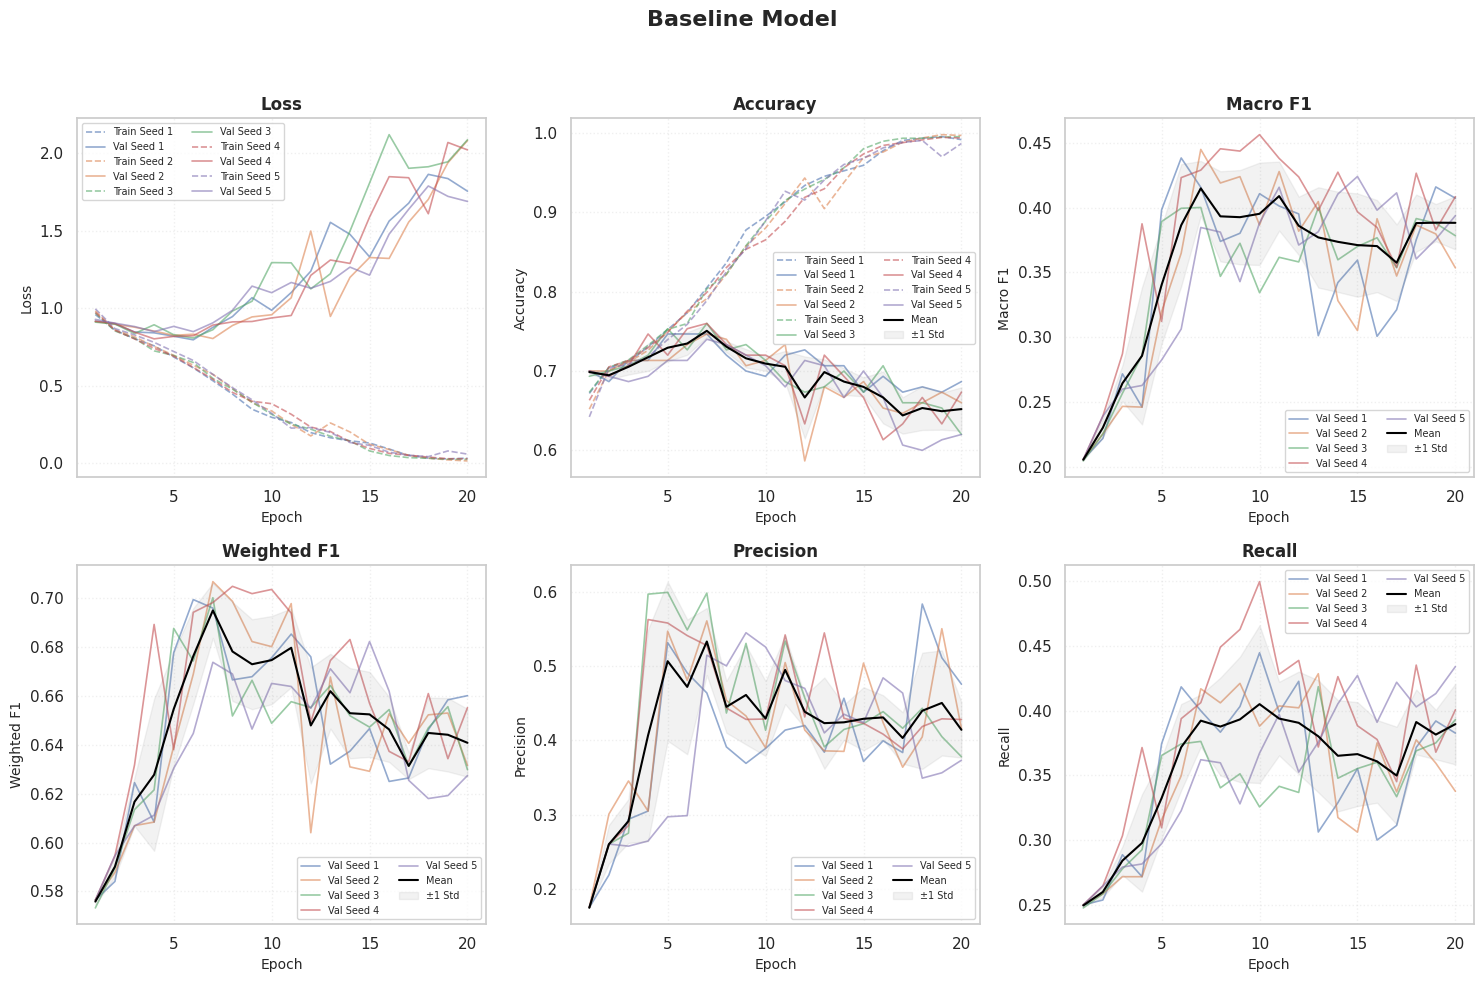

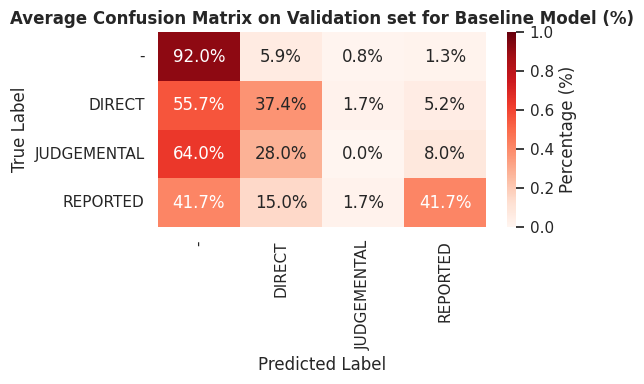


 Best epoch statistics (based on macro f1 score on validation set)
--------------------------------------------------------------------------------
╭───────────┬─────────────────╮
│ Metric    │ Mean ± Std      │
├───────────┼─────────────────┤
│ Loss      │ 0.9219 ± 0.1537 │
│ Accuracy  │ 0.7347 ± 0.0217 │
│ Precision │ 0.5003 ± 0.0696 │
│ Recall    │ 0.4276 ± 0.0401 │
╰───────────┴─────────────────╯

  F1 Scores:
╭───────────────────────┬─────────────────╮
│ Category              │ F1 Score        │
├───────────────────────┼─────────────────┤
│ Macro F1              │ 0.4327 ± 0.0193 │
│ Weighted F1           │ 0.6985 ± 0.0085 │
│ Class 0 (-)           │ 0.8552 ± 0.0123 │
│ Class 1 (DIRECT)      │ 0.4062 ± 0.0256 │
│ Class 2 (JUDGEMENTAL) │ 0.0000 ± 0.0000 │
│ Class 3 (REPORTED)    │ 0.4694 ± 0.1005 │
╰───────────────────────┴─────────────────╯




In [27]:
plot_histories_with_stats(baseline_all_histories, y_val=y_val, big_title='Baseline Model', cm_title='Average Confusion Matrix on Validation set for Baseline Model (%)')


Most metrics exhibit a **clear improvement during the early stages of training, with performance increasing steadily up to approximately the first ten epochs. Beyond this point, improvements largely plateau, and in some cases marginal fluctuations or degradations can be observed**.

A similar trend is visible for both accuracy and loss. However, when these validation curves are compared against their training counterparts, a marked discrepancy emerges. While validation accuracy follows the same general shape as training accuracy (rising until around the tenth epoch and then stabilizing or slightly decreasing) the magnitude of improvement on the validation set is considerably smaller and progresses more slowly. Also, validation loss begins to increase after roughly the same point at which other metrics stabilize, while training loss continues to decrease smoothly and without signs of convergence issues. This divergence between training and validation behavior provides strong evidence of **substantial overfitting in the Baseline model**.

The confusion matrix shows a strong bias toward the *Not sexist* class, which is the most frequent prediction across all true labels. As a result, most errors stem from misclassifications into this majority class, while confusions among the remaining classes are relatively rare.

Overall, the validation loss remains relatively high throughout training. The **average Macro F1 score on the validation set**, computed by averaging the best epoch of each seed, is approximately **0.43**.

These observations indicate that while the baseline model is able to fit the training data effectively, its generalization performance is limited, with early overfitting and a strong tendency to favor the dominant class.

## Stacked model evaluation

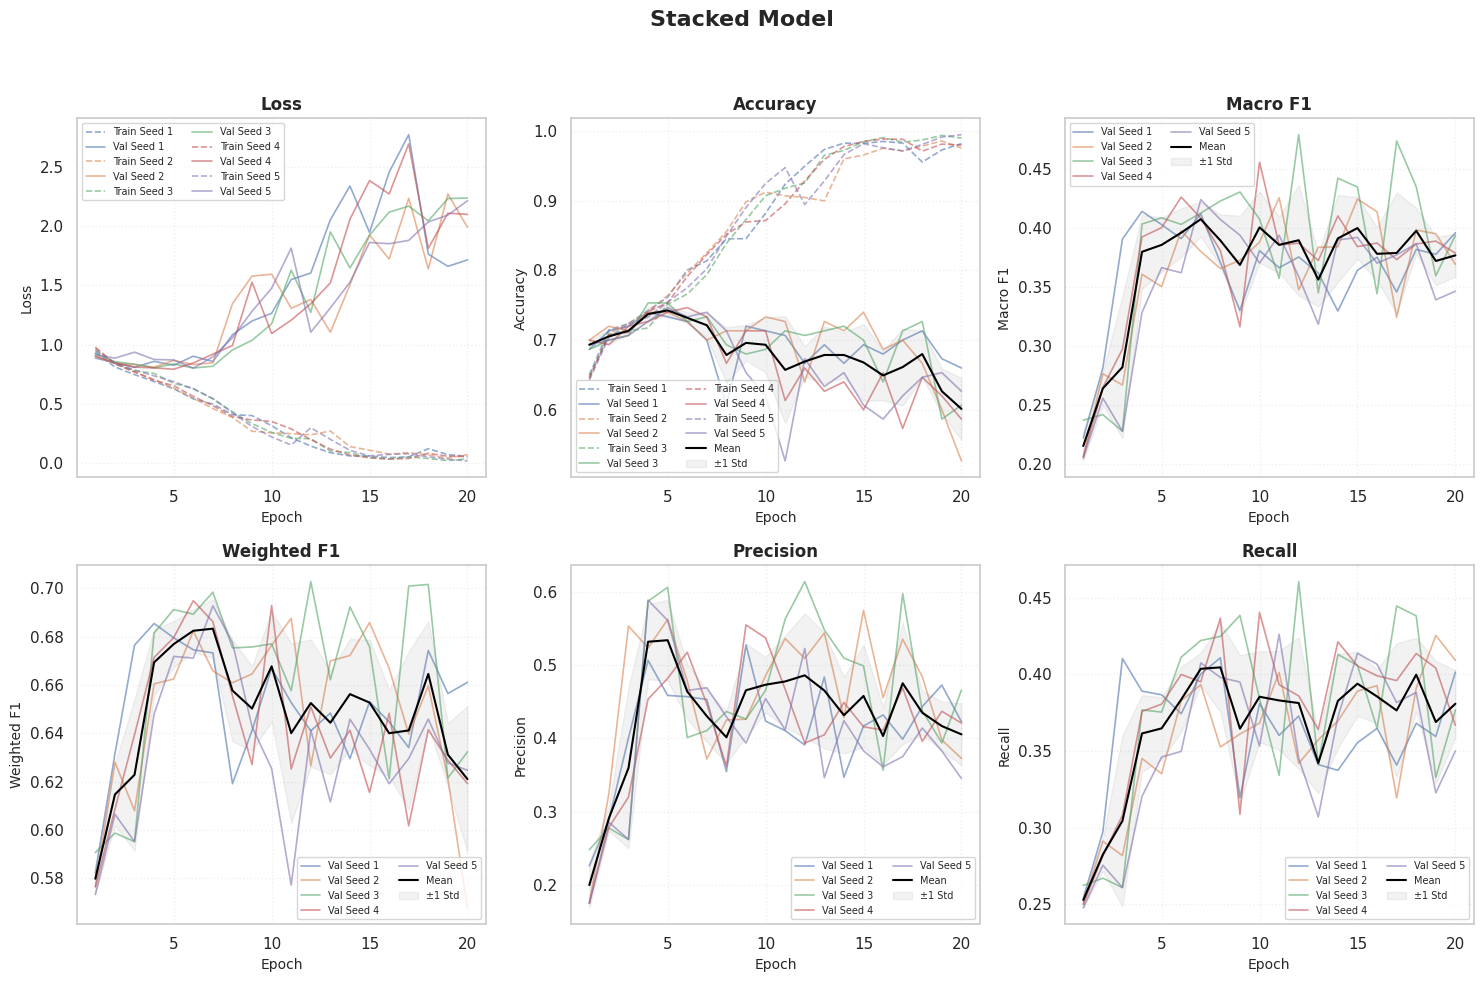

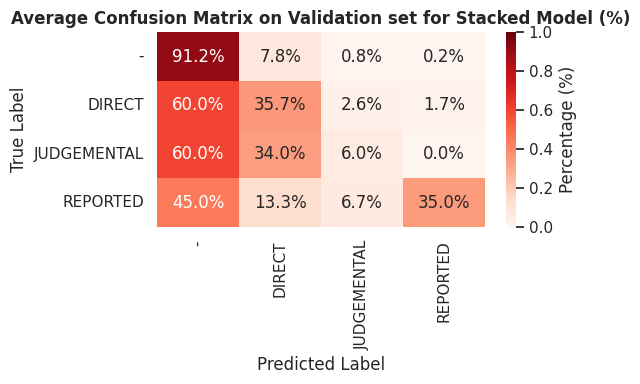


 Best epoch statistics (based on macro f1 score on validation set)
--------------------------------------------------------------------------------
╭───────────┬─────────────────╮
│ Metric    │ Mean ± Std      │
├───────────┼─────────────────┤
│ Loss      │ 1.0873 ± 0.1845 │
│ Accuracy  │ 0.7253 ± 0.0136 │
│ Precision │ 0.5327 ± 0.0477 │
│ Recall    │ 0.4197 ± 0.0265 │
╰───────────┴─────────────────╯

  F1 Scores:
╭───────────────────────┬─────────────────╮
│ Category              │ F1 Score        │
├───────────────────────┼─────────────────┤
│ Macro F1              │ 0.4397 ± 0.0241 │
│ Weighted F1           │ 0.6922 ± 0.0060 │
│ Class 0 (-)           │ 0.8475 ± 0.0093 │
│ Class 1 (DIRECT)      │ 0.3644 ± 0.0430 │
│ Class 2 (JUDGEMENTAL) │ 0.0500 ± 0.1000 │
│ Class 3 (REPORTED)    │ 0.4970 ± 0.0621 │
╰───────────────────────┴─────────────────╯




In [28]:
plot_histories_with_stats(stacked_all_histories, y_val=y_val, big_title='Stacked Model', cm_title='Average Confusion Matrix on Validation set for Stacked Model (%)')


The training dynamics of the Stacked model resemble those observed for the Baseline, and the same overfitting pattern is evident on this model. However, the gains during training are less pronounced and more gradual than those observed for the Baseline model. The Macro F1 score is slightly higher on average at the best epochs per each seed (**0.44**), indicating a modest overall improvement.

Inspection of the confusion matrices shows that the Baseline and Stacked models have very similar results across classes, both of them struggling to find *Judgemental* sentences.

## Comparison between Baseline and Stacked model

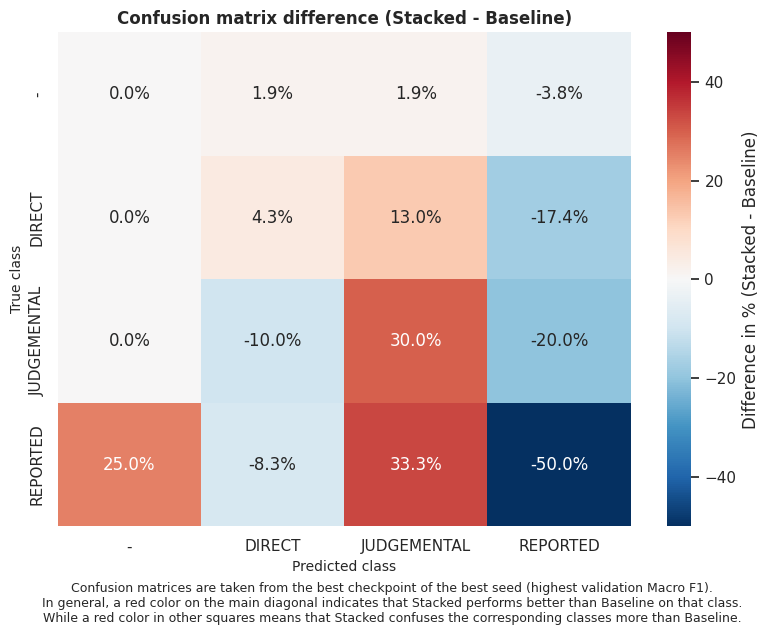

In [29]:
_ = plot_cm_difference_best_models(baseline_all_histories, stacked_all_histories)

The comparison between the best Baseline and Stacked confusion matrices shows that a few cells exhibit very similar values. 

The Stacked model clearly classifies better *Judgemental* class sentences, but achieves far worse results than the Baseline on *Reported* class.

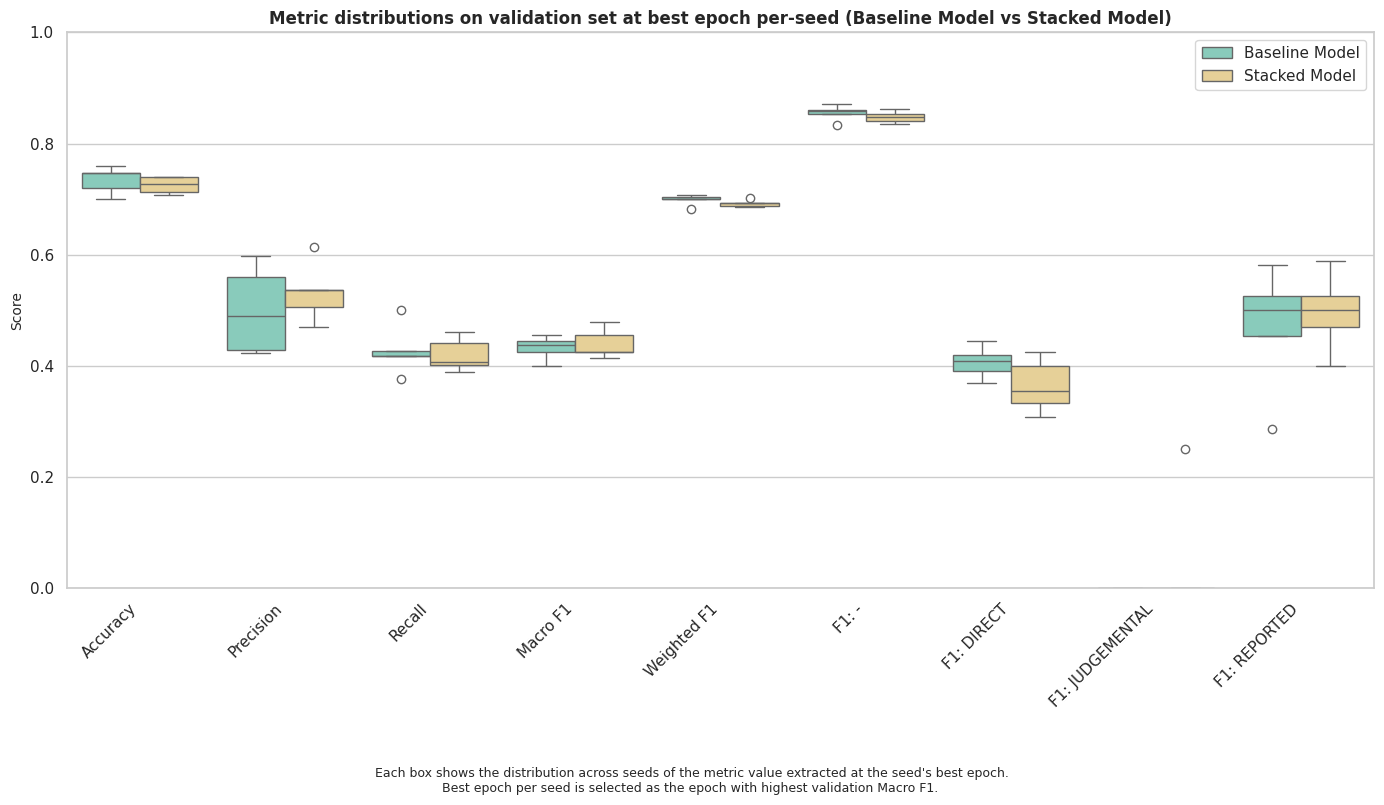

In [30]:
_ = plot_boxplot_metrics_comparison(
    baseline_all_histories,
    stacked_all_histories,
    model_labels=('Baseline Model', 'Stacked Model'),
    class_names=class_names,
    figsize=(14, 8),
    save_path=None,
    palette=['#7ED6C0', '#F3D58B']
)

The metric distributions on the validation set at the best epoch per seed confirm the trends observed in the previous analyses.

**Overall, the two models remain largely competitive across most metrics, rather than yielding a clear and consistent winner.**

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

In [32]:
import transformers

import json
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from transformers import AutoTokenizer, TFAutoModel
from tensorflow.keras import layers, models, optimizers


In [33]:

model_name = "cardiffnlp/twitter-roberta-base-hate"
tokenizer_roberta = AutoTokenizer.from_pretrained(model_name)
max_length = 128

def bert_encode(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors="tf"
    )
    return encoded['input_ids'], encoded['attention_mask']

print("Tokenization...")

X_train_ids, X_train_mask = bert_encode(training['tweet'], tokenizer_roberta)
y_train_roberta = training['label'].values

X_val_ids, X_val_mask = bert_encode(validation['tweet'], tokenizer_roberta)
y_val_roberta = validation['label'].values

X_test_ids, X_test_mask = bert_encode(test['tweet'], tokenizer_roberta)
y_test_roberta = test['label'].values

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Tokenization...


In [34]:
import keras

# wrapper layer for RoBERTa
@keras.saving.register_keras_serializable(package="CustomLayers")
class RobertaLayer(layers.Layer):
    def __init__(self, model_name, **kwargs):
        super().__init__(**kwargs)
        self.model_name = model_name  # store for get_config
        self.roberta = TFAutoModel.from_pretrained(model_name)
        self.roberta.trainable = False

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    def get_config(self):
        config = super().get_config()
        config.update({"model_name": self.model_name})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


def build_transformer_model(num_classes=4):
    input_ids = layers.Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
    attention_mask = layers.Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

    embeddings = RobertaLayer(model_name)([input_ids, attention_mask])

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3))(embeddings)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False, dropout=0.3))(x)

    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[input_ids, attention_mask], outputs=output)

    return model


In [35]:
# redefinition of old function to include transformer based model
def build_model(model='baseline'):
    """
    Build and compile a model.

    Args:
        model: 'baseline' or 'stacked'

    Returns:
        Compiled Keras model
    """
    if model == 'baseline':
        model = build_baseline_model(
            vocab_size, embedding_dim, embedding_matrix_np,
            hidden_units, num_classes, max_seq_len, trainable_emb=True
        )
    elif model == 'stacked':
        model = build_stacked_model(
            vocab_size, embedding_dim, embedding_matrix_np,
            hidden_units, num_classes, max_seq_len, trainable_emb=True
        )
    elif model == 'transformer':
        model = build_transformer_model()

    else:
        return None

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:

transformer_metrics_callback = ValidationMetricsCallback(
    validation_data=([X_val_ids, X_val_mask], y_val_roberta),
    num_classes=4
)

transformer_best_model, transformer_all_histories, transformer_best_seed, transformer_best_epoch = train_with_seeds(
    build_model_fn=build_model,
    model_type='transformer',
    X_train=[X_train_ids, X_train_mask],
    y_train=y_train_roberta,
    X_val=[X_val_ids, X_val_mask],
    y_val=y_val_roberta,
    seeds=seeds,
    epochs=20,
    batch_size=32,
    callbacks_list=[transformer_metrics_callback],
    verbose=True
)


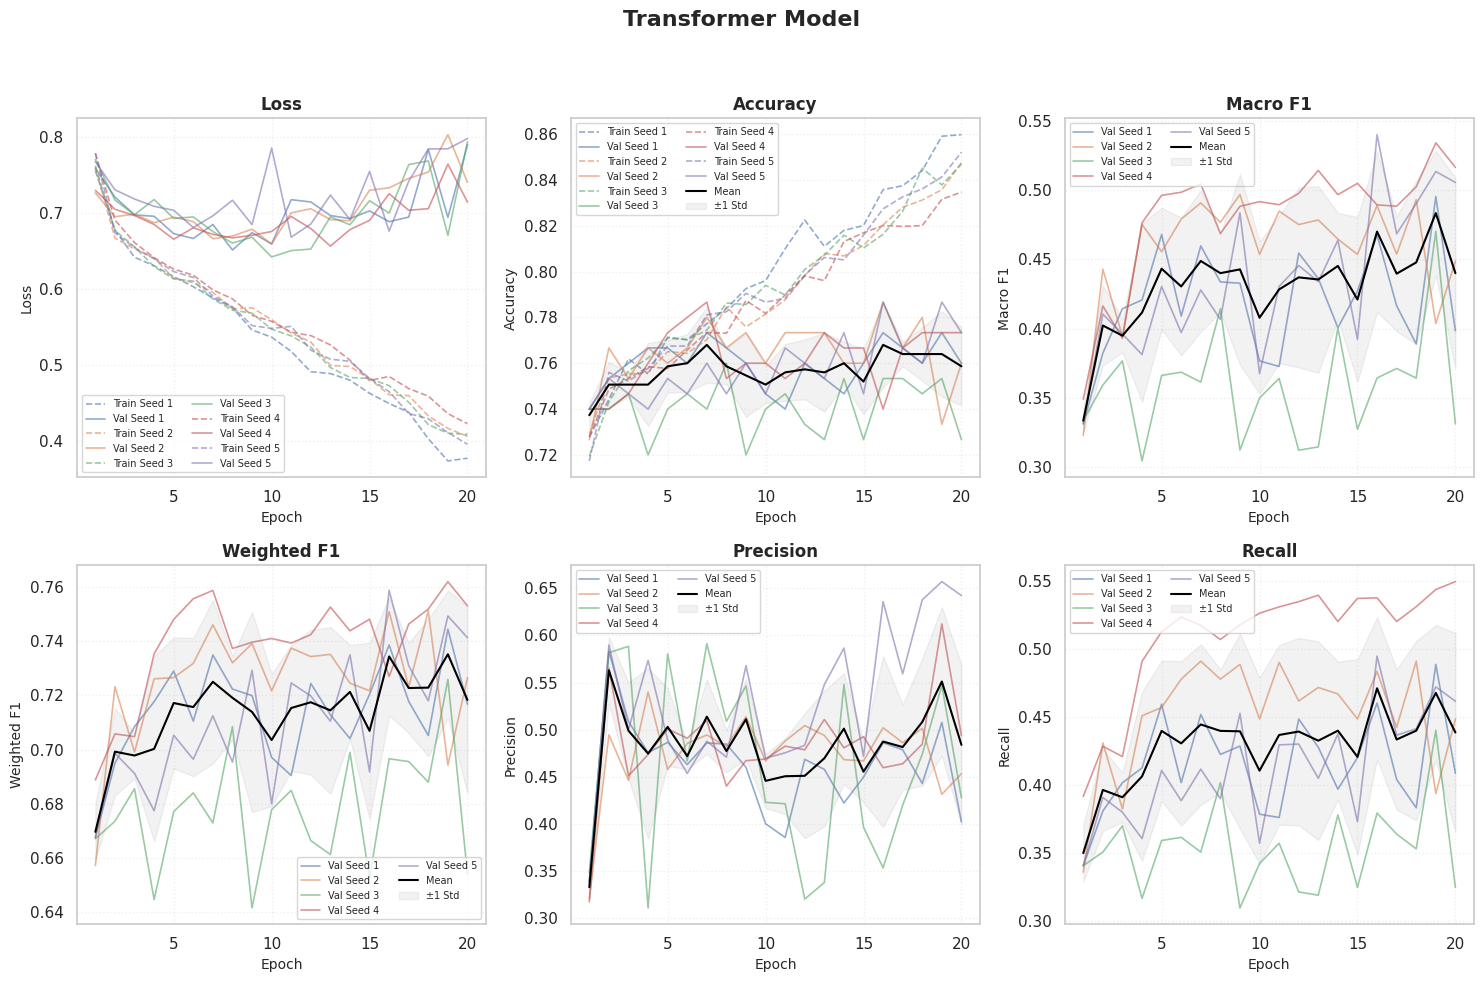

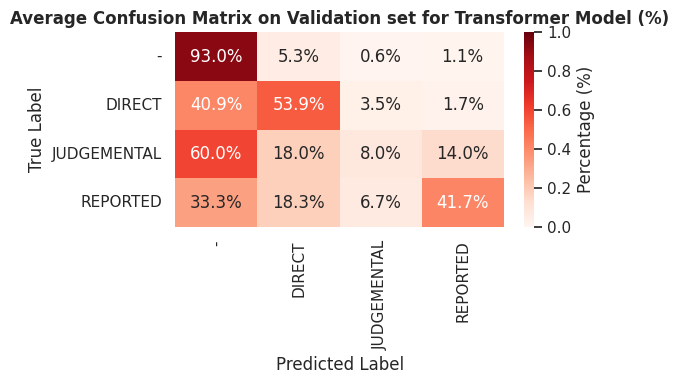


 Best epoch statistics (based on macro f1 score on validation set)
--------------------------------------------------------------------------------
╭───────────┬─────────────────╮
│ Metric    │ Mean ± Std      │
├───────────┼─────────────────┤
│ Loss      │ 0.6972 ± 0.0347 │
│ Accuracy  │ 0.7720 ± 0.0107 │
│ Precision │ 0.5633 ± 0.0519 │
│ Recall    │ 0.4913 ± 0.0328 │
╰───────────┴─────────────────╯

  F1 Scores:
╭───────────────────────┬─────────────────╮
│ Category              │ F1 Score        │
├───────────────────────┼─────────────────┤
│ Macro F1              │ 0.5076 ± 0.0262 │
│ Weighted F1           │ 0.7461 ± 0.0132 │
│ Class 0 (-)           │ 0.8793 ± 0.0098 │
│ Class 1 (DIRECT)      │ 0.5448 ± 0.0438 │
│ Class 2 (JUDGEMENTAL) │ 0.1117 ± 0.1021 │
│ Class 3 (REPORTED)    │ 0.4945 ± 0.0773 │
╰───────────────────────┴─────────────────╯




In [ ]:
plot_histories_with_stats(transformer_all_histories, y_val=y_val, big_title='Transformer Model', cm_title='Average Confusion Matrix on Validation set for Transformer Model (%)')


The training curves for the RoBERTa-based Transformer model exhibit signs of overfitting, although in contrast to the Baseline and Stacked models, the validation loss remains relatively stable and increases only slightly during later epochs.

**Unlike the previous models, the validation metrics here are less erratic across epochs: some random seeds start at lower performance levels and consistently remain lower throughout training**. This behavior highlights the strong dependence of the model's performance on the initialization seed, which affects the trainable components (the bidirectional LSTM layers and the final dense layer) since the RoBERTa encoder itself is frozen.

The confusion matrix indicates that the model maintains excellent performance on the Not sexist class, shows improved results compared to other models for Direct and Reported, but performs poorly on the Judgemental class. Similar to previous models, there is a clear bias toward predicting Not sexist, which the model assigns to many inputs.

**The model achieves a substantially higher average Macro F1 score at the best checkpoint per seed (0.50).**

Most diagonal cells are strongly red colored, indicating that the Transformer based model confuses classes less frequently than the Stacked model. Non diagonal cells are mostly blue colored, confirming more misclassifications from the Stacked model, with the notable exception of the *Judgemental* column, where the Transformer based model shows very poor performance

The validation metrics confirm that the RoBERTa based Transformer outperforms the Stacked model across most classes, except for *Judgemental*, where its performance is notably lower and surpasses the Stacked model only for the best seeds.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

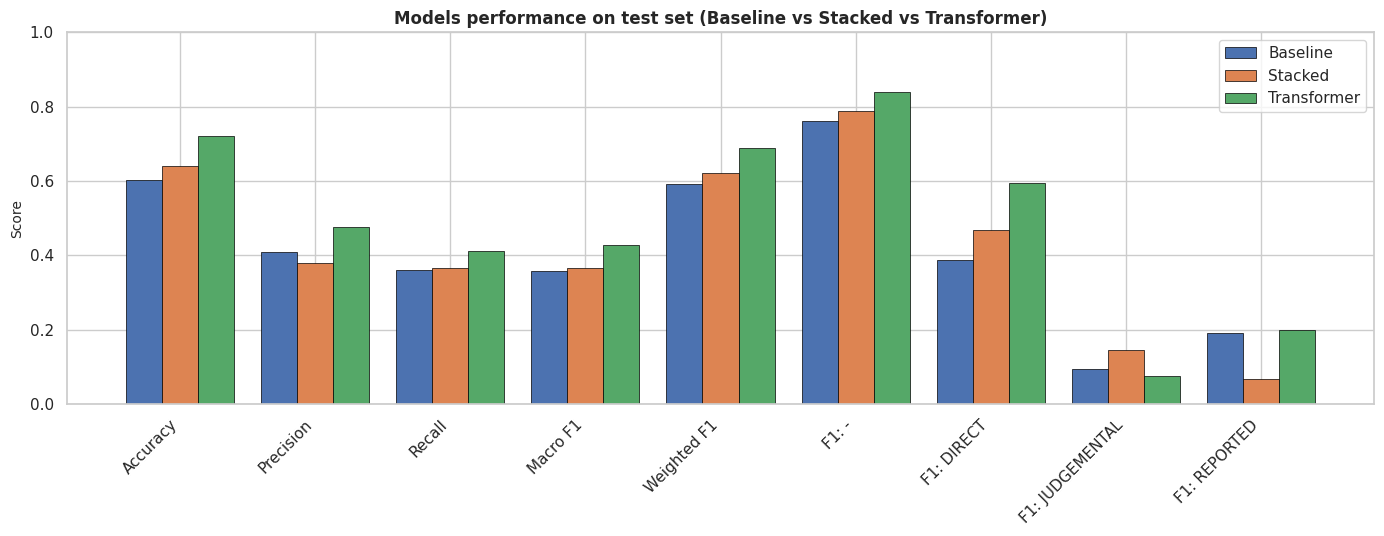

In [38]:
_, _, stats_test = barplot_multimodel(
    [baseline_best_model, stacked_best_model, transformer_best_model],
    [X_test, X_test, [[X_test_ids, X_test_mask]]],
    y_test,
    ["Baseline", "Stacked", "Transformer"],
    figsize=(14, 6),
    save_path=None,
    palette=None,
)

The comparison on the test set shows a clear and consistent performance hierarchy across all evaluated metrics. **The Transformer-based model achieves the highest scores by a substantial margin**, followed by the stacked model, which in turn slightly outperforms the baseline. This relative ordering is preserved across accuracy, precision, recall, and all F1-based measures, indicating a stable performance pattern rather than isolated improvements on specific metrics.

When considering class-wise F1 scores, **the lowest values are observed for the Judgemental and Reported classes** across all models. **This behavior is likely influenced by the intrinsic difficulty of these categories**: correct classification requires not only identifying sexist content, but also determining that the sexist behavior or viewpoint is attributed to a third party rather than directly expressed by the author, and in some cases assessing whether it is being condemned or merely reported. In addition, **this trend is plausibly exacerbated by the strong class imbalance in the dataset**, as shown in the table immediately below, where Judgemental and Reported instances constitute only a small fraction of both the training and test sets compared to the other classes.

Overall, the results suggest that while architectural differences translate into systematic performance gains, class-specific challenges and data distribution effects remain evident in the final evaluation.

In [39]:
print("Baseline Macro F1 on Test set: ", stats_test['Baseline']['values'][3])
print("Stacked Macro F1 on Test set: ", stats_test['Stacked']['values'][3])
print("Transformer Macro F1 on Test set: ", stats_test['Transformer']['values'][3])

Baseline Macro F1 on Test set:  0.35874249365297955
Stacked Macro F1 on Test set:  0.3674590967273894
Transformer Macro F1 on Test set:  0.42780308200155526


In [40]:
print("Baseline Accuracy on Test set: ", stats_test['Baseline']['values'][0])
print("Stacked Accuracy on Test set: ", stats_test['Stacked']['values'][0])
print("Transformer Accuracy on Test set: ", stats_test['Transformer']['values'][0])

Baseline Accuracy on Test set:  0.6035714149475098
Stacked Accuracy on Test set:  0.6392857432365417
Transformer Accuracy on Test set:  0.7214285714285714


In [ ]:
test_not_sexist = (test['label'] == 1).sum()
print("Number of instances per class (Test, Train)")
print("Not sexist: ", (test['label'] == 0).sum(), "|", (training['label'] == 0).sum())
print("Direct:     ", (test['label'] == 1).sum(), " |", (training['label'] == 1).sum())
print("Judgemental:", (test['label'] == 2).sum(), " |", (training['label'] == 2).sum())
print("Reported:   ", (test['label'] == 3).sum(), " |", (training['label'] == 3).sum())


Number of instances per class (Test, Train)
Not sexist:  179 | 2014
Direct:      62  | 537
Judgemental: 18  | 138
Reported:    21  | 184


In [41]:
# compute values for plotting

baseline_y_pred = model_predict_labels(baseline_best_model, X_test)
stacked_y_pred = model_predict_labels(stacked_best_model, X_test)
transformer_y_pred = model_predict_labels(transformer_best_model, [X_test_ids, X_test_mask])

all_models_correct_tweets_mask = all_correct_mask([baseline_y_pred, stacked_y_pred, transformer_y_pred], y_test).astype(bool)
all_models_correct_tweets = test.loc[all_models_correct_tweets_mask, 'tweet'].tolist()
y_test_all_models_correct = y_test[all_models_correct_tweets_mask]

all_models_wrong_tweets_mask = all_wrong_mask([baseline_y_pred, stacked_y_pred, transformer_y_pred], y_test).astype(bool)
all_models_wrong_tweets = test.loc[all_models_wrong_tweets_mask, 'tweet'].tolist()
y_test_all_models_wrong = y_test[all_models_wrong_tweets_mask]

baseline_correct_tweets_mask = all_correct_mask([baseline_y_pred], y_test).astype(bool)
baseline_correct_tweets = test.loc[baseline_correct_tweets_mask, 'tweet'].tolist()
y_test_baseline_correct = y_test[baseline_correct_tweets_mask]

baseline_wrong_tweets_mask = all_wrong_mask([baseline_y_pred], y_test).astype(bool)
baseline_wrong_tweets = test.loc[baseline_wrong_tweets_mask, 'tweet'].tolist()
y_test_baseline_wrong = y_test[baseline_wrong_tweets_mask]

stacked_correct_tweets_mask = all_correct_mask([stacked_y_pred], y_test).astype(bool)
stacked_correct_tweets = test.loc[stacked_correct_tweets_mask, 'tweet'].tolist()
y_test_stacked_correct = y_test[stacked_correct_tweets_mask]

stacked_wrong_tweets_mask = all_wrong_mask([stacked_y_pred], y_test).astype(bool)
stacked_wrong_tweets = test.loc[stacked_wrong_tweets_mask, 'tweet'].tolist()
y_test_stacked_wrong = y_test[stacked_wrong_tweets_mask]

transformer_correct_tweets_mask = all_correct_mask([transformer_y_pred], y_test).astype(bool)
transformer_correct_tweets = test.loc[transformer_correct_tweets_mask, 'tweet'].tolist()
y_test_transformer_correct = y_test[transformer_correct_tweets_mask]

transformer_wrong_tweets_mask = all_wrong_mask([transformer_y_pred], y_test).astype(bool)
transformer_wrong_tweets = test.loc[transformer_wrong_tweets_mask, 'tweet'].tolist()
y_test_transformer_wrong = y_test[transformer_wrong_tweets_mask]

## Analysis of Some Difficult Examples

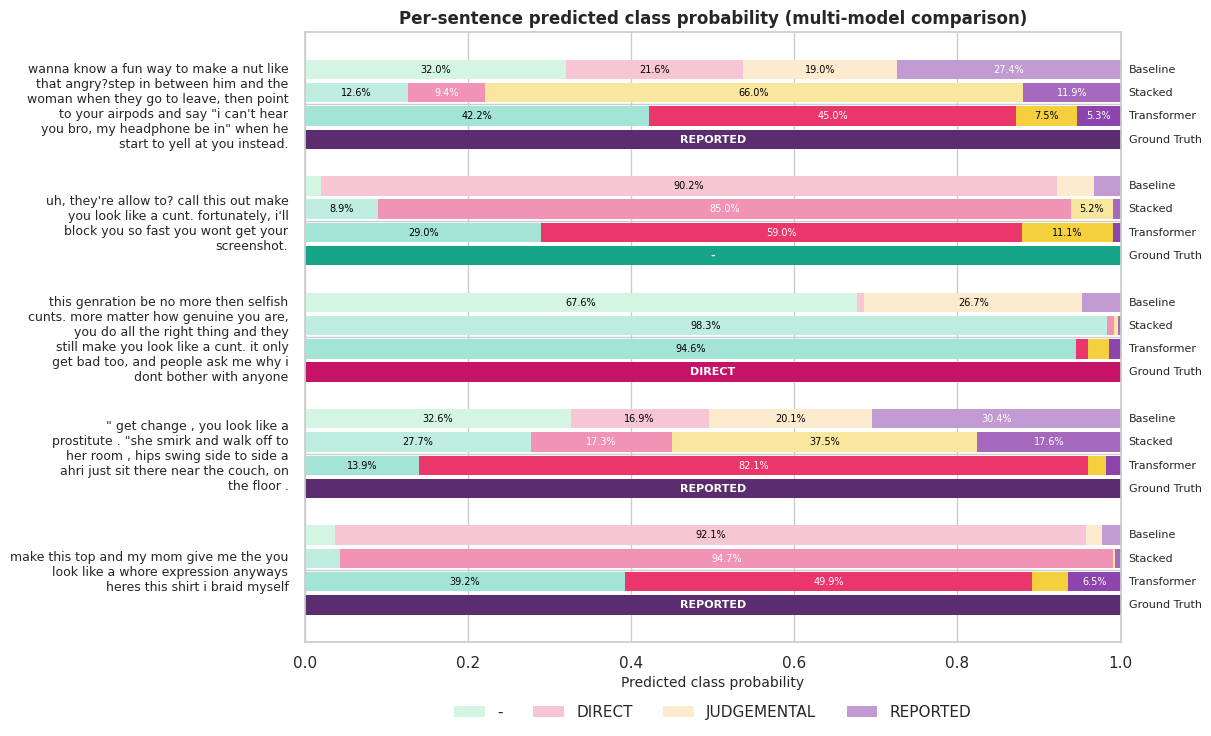

In [42]:
all_probs, fig, ax = plot_multi_model_sentence_probability_bars(
    sentences=all_models_wrong_tweets[-5:],
    models=[baseline_best_model, stacked_best_model, transformer_best_model],
    ground_truth=y_test_all_models_wrong[-5:],
    model_names=['Baseline', 'Stacked', 'Transformer'],
    tokenizers=[tokenizer, tokenizer, tokenizer_roberta],
    tokenizer_types=['whitespace', 'whitespace', 'hf'],
    max_lens=[max_seq_len, max_seq_len, 128],
)

The above plot shows, for each selected sentence, the output probability distributions produced by each model. The sentences were chosen among those misclassified by all three models in the test set, and the plot illustrates how the models behave when faced with particularly challenging inputs.

`> @rachelnabors Wanna know a fun way to make a nut like that angry?Step in between him and the women when they go to leave, then point to your airpods and say "I can't hear you bro, my headphones are in" when he starts to yell at you instead.` - *Reported*

Here, the sexist behavior is reported in a very subtle manner and hinges on only noe word. **The key here is the word “instead” at the end of the sentence, which implies that the man’s aggressive behavior was originally directed toward a woman rather than the author**. This inference is essential to interpret the described behavior as sexist rather than merely aggressive.

Furthermore, the distinction between *Reported* and *Judgemental* sexism is particularly ambiguous in this case. The author does not neutrally describe the behavior but rather frames it in a clearly critical tone (*a nut like that*), suggesting that *Judgemental* might be a more appropriate label. This ambiguity likely contributes to the models’ difficulty in correctly classifying the sentence.

`"> This genration are no more then selfish cunts. More matter how genuine you are, you do all the right things and  they still make you look like a cunt. It’s only getting worse too, and people ask me why I don’t bother with anyone` - *Direct*

This sentence is labeled as *Direct* sexism but is classified as *Not sexist* by all models. In isolation, the sentence does not contain any explicit gender-based references or sexist intent. The use of profanity alone is insufficient to establish sexism, and the main theme appears to be a generalized criticism of "this (younger?) generation." Without additional context, the *Direct* label is difficult to justify, suggesting that **this example may represent an annotation error within the dataset**.

`> " get changed , you look like a prostitute . "She smirked and walked off to her room , hips swinging side to side as Ahri just sat there near the couch, on the floor . https://t.co/hWowZcLPH8` - *Reported*

In this case, both the Baseline and Stacked models appear to be confused by the narrative structure of the sentence. The sexist remark is reported at the beginning, but it is followed by a descriptive passage that may be interpreted as a form of narrative distancing or implicit condemnation. Both the Baseline and the Stacked models produce a high entropy output distribution, reflecting genuine model uncertainty rather than a confident misclassification.

### Below, we report a selection of examples extracted from the training set. All of the following sentences are labeled as *Direct* sexism.

For several reasons, these classification models may struggle to correctly interpret certain sentences. These difficulties often arise from the need for external or background knowledge, the presence of implicit references to events or individuals, the use of slang, acronyms, neologisms, and the inherent challenge of inferring the author’s intent. In many cases, correct interpretation requires the ability to read beyond the literal content of the sentence and to incorporate contextual information that is not explicitly present in the text.


> `Anita as an asset? Damn I should've considered that. Her vs gamergate was one big spectacle https://t.co/x2k5KDnUt2`

This sentence relies heavily on **external knowledge**. The reference to Gamergate implicitly evokes a broader context of online harassment and sexism, but the term itself does not convey this meaning without prior knowledge of the event. Similarly, the mention of Anita is ambiguous in isolation and does not clearly identify a public figure or the role she played in the controversy. Without this background information, the sentence is difficult to interpret correctly, even for a human reader unfamiliar with the topic.

> `Now the MRA/MGTOW/INCEL crowd will double up on their online woman-hating angries.Because it's usually Women who turn these chomos in. Who then run and hide in the prison church. Then get out and find a new career in Qristianity. And abuse people again. https://t.co/OIIkwtU8ND`

Some tweets are challenging due to the extensive use of **acronyms and highly domain specific jargon**. Terms such as *MRA*, *MGTOW*, and *INCEL* encode complex ideological positions that are not transparent at the surface level. Without explicit expansion or contextual cues, models may fail to correctly capture the semantic and pragmatic implications of these references.

> `black femcels, nigcels, hoteps, d!vestors, femininity nuts, black luxury ppl, black mgtow &amp; other online groups fascinate me LOLthe way they twist legitimate ideas abt race and oppression to fit their catastrophizing worldview + inform behavior that leads them back to ws is…`

Other sentences introduce **neologisms** or creatively constructed terms. These expressions are often morphologically complex and semantically loaded, making them difficult to tokenize and interpret, especially for word based tokenizers.

> `@VitamnZebra @Waandyl @jazIynns Ayo, call me sexist but both of yall need to shut the fuck up`

In this case, **the sentence cannot be fully interpreted without access to the surrounding conversation**. The explicit self labeling as sexist is the only cue suggesting a sexist intent, yet no sexist content is directly observable in the sentence itself. Correct classification would therefore require conversational context rather than world knowledge.

> `Who wants to play? I’m horny.   #horny #cum #porn #masturbate #jackoff #voyeur #bigdick #bigcock #bigload #cumshot #cumtribute #ridemydick #blowjob #handjob #snapfun #pussy #eatass #skypesex #cock #watchmecum #naughty #jerkoff #jackoff #snapme #voyeurist #wankchat #morningwood https://t.co/Qwd6BnIZDs`

This example illustrates a strong dependence on the social and situational context in which the message is posted. The same content could be considered acceptable or inappropriate depending on the platform, audience, or community norms. Such pragmatic distinctions are not encoded in the text alone and are therefore inaccessible to models trained solely on sentence inputs.

### Noisy or questionable annotations

**Some training examples appear to be incorrectly labeled as Direct sexism, introducing noise into the dataset and potentially affecting model performance.**

> `Does anyone else remember when the character customization screen in wow got updated and the female priest robe had a triangular boob window that was patched out a week later or did I hallucinate that`

Although the sentence references a female body part, it does so in a descriptive and non judgmental manner. **There is no explicit sexist intent or derogatory framing, making the Direct label difficult to justify.**

> `Transphobes are so weak and cowardly that instead of going after real misogyny &amp; the patriarchy, they resort to targeting a different vulnerable group and become the abusers themselves in order to feel powerful. I see you. The bullied becoming the bullies isn't a cool look. https://t.co/bjTsJ2a77L`

Here, the author explicitly condemns transphobia and misogyny rather than endorsing them. While the topic relates to gender based conflict, the stance expressed is oppositional rather than sexist. This example lies in a gray area thematically, but it does not exhibit clear elements of direct sexism.

## Sentence length analysis

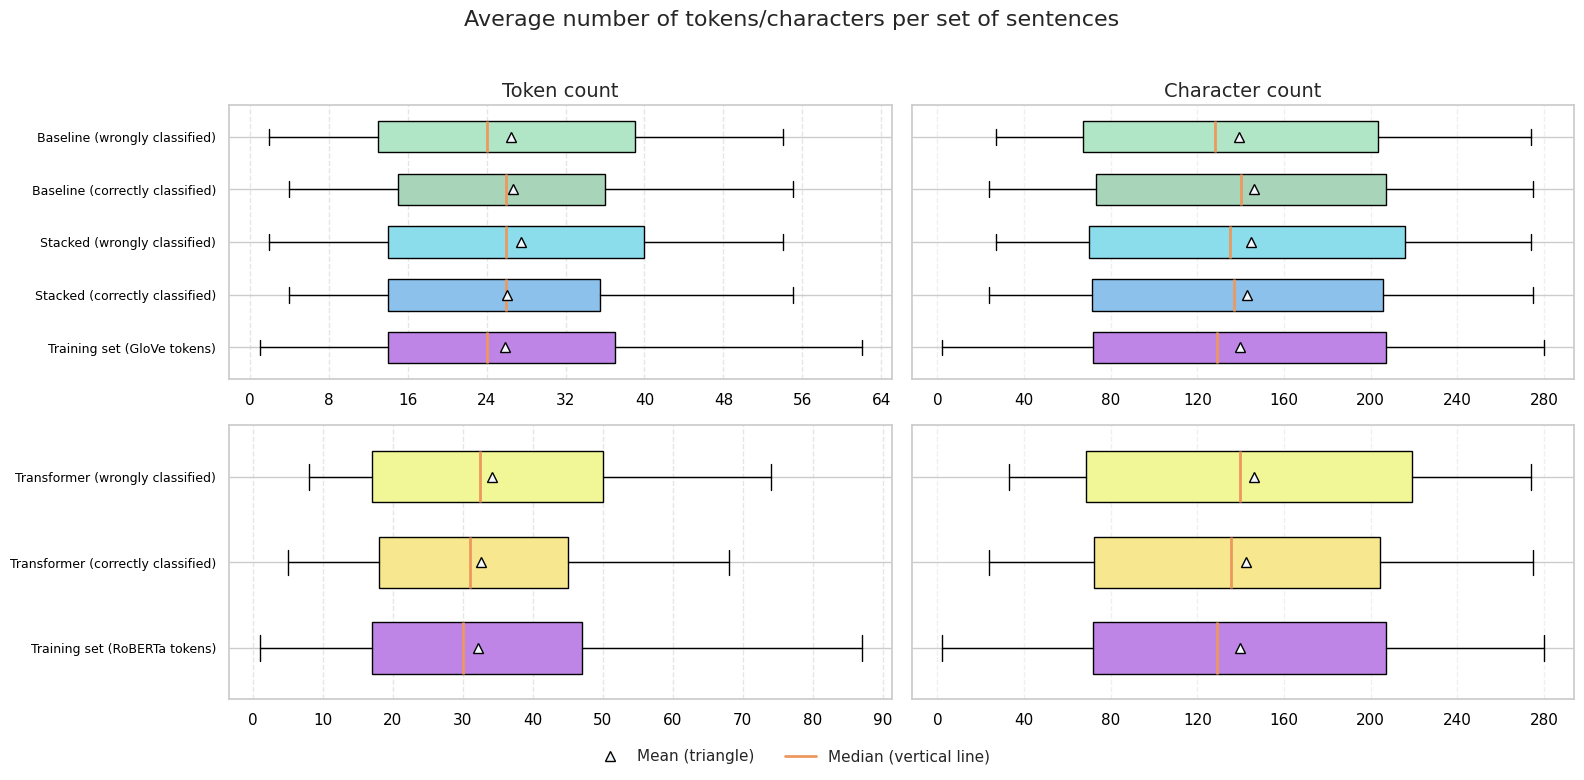



| dataset                            | tokens (mean ± std, n)   | chars (mean ± std, n)   |
|:-----------------------------------|:-------------------------|:------------------------|
| Baseline (wrongly classified)      | 26.44 ± 14.39 (n=111)    | 139.41 ± 76.33 (n=111)  |
| Baseline (correctly classified)    | 26.72 ± 12.93 (n=169)    | 146.27 ± 73.13 (n=169)  |
| Stacked (wrongly classified)       | 27.51 ± 14.28 (n=101)    | 144.79 ± 76.15 (n=101)  |
| Stacked (correctly classified)     | 26.10 ± 13.05 (n=179)    | 142.85 ± 73.53 (n=179)  |
| Training set (GloVe tokens)        | 25.83 ± 13.93 (n=2873)   | 139.66 ± 76.16 (n=2873) |
| Transformer (wrongly classified)   | 34.22 ± 18.24 (n=78)     | 145.97 ± 79.53 (n=78)   |
| Transformer (correctly classified) | 32.68 ± 16.24 (n=202)    | 142.61 ± 72.42 (n=202)  |
| Training set (RoBERTa tokens)      | 32.25 ± 17.41 (n=2873)   | 139.66 ± 76.16 (n=2873) |


In [43]:
datasets = [
    baseline_wrong_tweets,
    baseline_correct_tweets,
    stacked_wrong_tweets,
    stacked_correct_tweets,
    training['tweet'].to_list(),
    transformer_wrong_tweets,
    transformer_correct_tweets,
    training['tweet'].to_list(),
]
names = [
    "Baseline (wrongly classified)",
    "Baseline (correctly classified)",
    "Stacked (wrongly classified)",
    "Stacked (correctly classified)",
    "Training set (GloVe tokens)",
    "Transformer (wrongly classified)",
    "Transformer (correctly classified)",
    "Training set (RoBERTa tokens)",
]
tokenizers = [
    tokenizer, tokenizer, tokenizer, tokenizer, tokenizer,
    tokenizer_roberta, tokenizer_roberta, tokenizer_roberta
]
groups = [[0, 1, 2, 3, 4], [5, 6, 7]]

fig, axes, stats = plot_lengths_groups_grid(
    datasets=datasets,
    names=names,
    tokenizers=tokenizers,
    groups=groups,
    figsize=(16, 8),
    title="Average number of tokens/characters per set of sentences"
)

The comparison between correctly and incorrectly classified instances shows no substantial differences in average sentence length, both in terms of tokens and characters, across the evaluated models. This suggests that **sentence length alone is not a discriminative factor for classification errors in this task**.

Notably, for the Transformer-based model, correctly classified sentences are on average slightly longer than misclassified ones, indicating that increased input length does not negatively impact performance.

However, it's worth noting that the average sentence length in the training set is substantially shorter than in the test set, both in terms of token and character counts.

The substantially larger average token count observed with the RoBERTa tokenizer indicates a finer grained segmentation of the same input text, with tokens that are on average shorter than those produced by the GloVe-based tokenizer.

Obviously, the training set statistics reported in terms of character length are identical across tokenizers, as they refer to the same measure and are unaffected by the choice of tokenization.

Finally, on a purely statistical note, in nearly all distributions the mean exceeds the median, indicating a consistent right skew with a few longer sentences pulling the average above the central tendency.

## Evaluation of Out of Vocabulary Tokens

In [45]:
print(f"{'Batch of sentences':<45}| {'Average number of unknown':<26}| {'Percentage of unknown tokens':<45}")
print(f"{'':<45}| {' tokens per sentence':<26}| {' per batch of sentences':<45}")

print(f"{'-'*45}|{'-'*27}|{'-'*45}")

baseline_wrong_stats = count_token_type_dataset(baseline_wrong_tweets, tokenizer, target_id=1, print_basic_results="Misclassified by baseline model")
stacked_wrong_stats  = count_token_type_dataset(stacked_wrong_tweets,  tokenizer, target_id=1, print_basic_results="Misclassified by stacked model")
transformer_wrong_stats = count_token_type_dataset(transformer_wrong_tweets, tokenizer_roberta, target_id=tokenizer_roberta.unk_token_id, print_basic_results="Misclassified by transformer model")

baseline_correct_stats = count_token_type_dataset(baseline_correct_tweets, tokenizer, target_id=1, print_basic_results="Correctly classified by baseline model")
stacked_correct_stats  = count_token_type_dataset(stacked_correct_tweets,  tokenizer, target_id=1, print_basic_results="Correctly classified by stacked model")
transformer_correct_stats = count_token_type_dataset(transformer_correct_tweets, tokenizer_roberta, target_id=tokenizer_roberta.unk_token_id, print_basic_results="Correctly classified by transformer model")

test_stats_glove = count_token_type_dataset(test['tweet'].to_list(), tokenizer, target_id=1, print_basic_results="Whole test set (GloVe tokenizer)")
test_stats_hf = transformer_stats = count_token_type_dataset(test['tweet'].to_list(), tokenizer_roberta, target_id=tokenizer_roberta.unk_token_id, print_basic_results="Whole test set (RoBERTa tokenizer)")
training_stats_glove = count_token_type_dataset(training['tweet'].to_list(), tokenizer, target_id=1, print_basic_results="Whole training set (GloVe tokenizer)")
training_stats_hf = transformer_stats = count_token_type_dataset(training['tweet'].to_list(), tokenizer_roberta, target_id=tokenizer_roberta.unk_token_id, print_basic_results="Whole training set (RoBERTa tokenizer)")


Batch of sentences                           | Average number of unknown | Percentage of unknown tokens                 
                                             |  tokens per sentence      |  per batch of sentences                      
---------------------------------------------|---------------------------|---------------------------------------------
Misclassified by baseline model              | 1.75                      | 6.61 %
Misclassified by stacked model               | 2.00                      | 7.27 %
Misclassified by transformer model           | 0.00                      | 0.00 %
Correctly classified by baseline model       | 1.90                      | 7.11 %
Correctly classified by stacked model        | 1.75                      | 6.70 %
Correctly classified by transformer model    | 0.00                      | 0.02 %
Whole test set (GloVe tokenizer)             | 1.84                      | 6.91 %
Whole test set (RoBERTa tokenizer)           | 0.00             

The Transformer based model exhibits a negligible proportion of unknown tokens, which may be attributed to the subword based tokenization strategy employed by RoBERTa. By decomposing words into shorter subword units, this tokenizer effectively mitigates out-of-vocabulary issues, resulting in near-complete coverage of the input text.

**The proportion of unknown tokens shows minimal variation between correctly and incorrectly classified sentences** across all three models, which may indicate that **this feature plays a limited role in determining classification errors**. Nevertheless, it can be observed that **the Transformer based model, which exhibits a substantially lower incidence of unknown tokens overall, also achieves better performance**. This difference, however, cannot be directly attributed to token coverage alone and may instead reflect the impact of a more suitable architecture and RoBERTa's hate speech pre-training.

In [46]:
print(f"{'dataset/tokenizer':<{30}}{'total unknown tokens':>{25}}{'unique unknown tokens':>{25}}")
print("-" * (30 + 25 * 2))

print(f"{'Test set (glove tokenizer)':<{30}}{int(test_stats_glove.get('n_target_tokens',0)):{25},}{len(test_stats_glove.get('unknown_counts',{})):{25},}")
print(f"{'Test set (roberta tokenizer)':<{30}}{int(test_stats_hf.get('n_target_tokens',0)):{25},}{len(test_stats_hf.get('unknown_counts',{})):{25},}")
print(f"{'Train set (glove tokenizer)':<{30}}{int(training_stats_glove.get('n_target_tokens',0)):{25},}{len(training_stats_glove.get('unknown_counts',{})):{25},}")
print(f"{'Train set (roberta tokenizer)':<{30}}{int(training_stats_hf.get('n_target_tokens',0)):{25},}{len(training_stats_hf.get('unknown_counts',{})):{25},}")

dataset/tokenizer                  total unknown tokens    unique unknown tokens
--------------------------------------------------------------------------------
Test set (glove tokenizer)                          515                      505
Test set (roberta tokenizer)                          1                        1
Train set (glove tokenizer)                           0                        0
Train set (roberta tokenizer)                        29                        1


We also observed that **when restricting the GloVe-based vocabulary to tokens appearing in the training set only, the test set contains approximately 900 unknown tokens**, the vast majority of which are unique, with the remaining ones occurring at most twice. Expanding the vocabulary to include all available GloVe tokens reduces the number of unknown tokens in the test set to approximately 500.

In [47]:
print("> Test set (GloVe tokenizer) unique unknown tokens (random 20):")
print(" ", "\n  ".join(list(test_stats_glove.get("unknown_counts").keys())[:20]))

print("\n> Train set (GloVe tokenizer) unique unknown tokens:")
print(" ", "\n  ".join(training_stats_glove.get("unknown_counts")))

print("\n> Test set (roberta tokenizer) unique unknown tokens:")
print(" ", "\n  ".join(test_stats_hf.get("unknown_counts")))

print("\n> Train set (roberta tokenizer) unique unknown tokens:")
print(" ", "\n  ".join(training_stats_hf.get("unknown_counts")))


> Test set (GloVe tokenizer) unique unknown tokens (random 20):
  ny!
  same,
  though!!!
  mmm,
  canhe
  neck.
  together?
  'gender'
  inferring.
  country,
  harassment".female
  monday,
  tuesday,
  thursday,
  males.
  unshocking.
  identity!
  won.
  orientation"parents
  children.that

> Train set (GloVe tokenizer) unique unknown tokens:
  

> Test set (roberta tokenizer) unique unknown tokens:
  !!

> Train set (roberta tokenizer) unique unknown tokens:
  !!


In [48]:
"orientation" in vocab and '"' in vocab and "parents" in vocab

True

GloVe based tokenizer isn't able to tokenize correctly *`orientation"parents`* even though all of its components are part of its vocabulary.

In [49]:
def split_strings_on_chars(strings, dividers):
    import re

    result = []
    for s in strings:
        if not dividers:
            continue

        pattern = r'[{}]'.format(re.escape(''.join(dividers)))
        parts = re.split(pattern, s)
        parts = [p for p in parts if p]
        result.extend(parts)

    return result

# we create a new array, splitting word on punctuation
punctuation = [".", ",", "!", "?", "-", "'", '"']
punctuation_split_tokens = split_strings_on_chars(list(test_stats_glove.get("unknown_counts").keys()), punctuation)

# then, we select only words not appearing in GloVe vocabulary
really_unknown_tokens = [token for token in punctuation_split_tokens if token not in vocab]
print(len(really_unknown_tokens))

125


A manual inspection revealed that **a large portion of the unknown tokens in the test set were artifacts of punctuation handling** (e.g., words followed by commas or exclamation marks, or containing internal punctuation): a problem arising from the input parsing prior to the tokenization process. By manually inspecting and correcting these cases, we isolated a smaller set of tokens that are effectively absent from the GloVe vocabulary. The remaining tokens predominantly consist of malformed inputs, including concatenated words where whitespace is missing [*obstetricianpsychologist*, *rhymesgetting*, *lovecouple*], common typographical errors [*patroitic*, *femism*], highly irregular or non interpretable strings [*uspsnwomskw*, *nkwasia*], as well as exaggerated or emphatic variants of otherwise standard words [*boobieeeessssss*].

**Such artifacts could likely have been mitigated through a more robust preprocessing pipeline, for instance by explicitly separating punctuation from surrounding text via whitespace normalization.**

In [50]:
vocab_roberta = tokenizer_roberta.get_vocab()
tokens_by_id_roberta = tokenizer_roberta.convert_ids_to_tokens(list(range(len(vocab_roberta))))
print(tokens_by_id_roberta[:20])

['<s>', '<pad>', '</s>', '<unk>', '.', 'Ġthe', ',', 'Ġto', 'Ġand', 'Ġof', 'Ġa', 'Ġin', '-', 'Ġfor', 'Ġthat', 'Ġon', 'Ġis', 'âĢ', "'s", 'Ġwith']


In [51]:
print("GloVe   vocabulary size: ", len(vocab))
print("RoBERTa vocabulary size: ", len(vocab_roberta))

GloVe   vocabulary size:  406158
RoBERTa vocabulary size:  50265


The RoBERTa tokenizer relies on a byte level Byte Pair Encoding (BPE) scheme, which decomposes input text into subword units learned from data rather than operating at the word level. Word boundaries are implicitly encoded through whitespace indicators within the token vocabulary, while rare or previously unseen word forms can be represented as sequences of smaller subword or byte-level tokens. This approach enables a relatively compact vocabulary to achieve broad lexical coverage, effectively handling morphological variation, informal language, and OOV words. As a consequence, **RoBERTa can tokenize the vast majority of inputs with a negligible number of unknown tokens, despite having a substantially smaller vocabulary than word level models based on GloVe**.

In [ ]:
"Italy" in vocab

False

In [52]:
print("RoBERTa tokenizer: token usage statistics on the test set")
_ = summarize_token_usage(tokenizer_roberta, X_test_ids)
print("RoBERTa tokenizer: token usage statistics on the training set")
_ = summarize_token_usage(tokenizer_roberta, X_train_ids)

RoBERTa tokenizer: token usage statistics on the test set
Unique tokens used                       |   2550 / 50265  ( 5.07%)
Avg tokens per sentence (non-pad)        |  33.11
Avg unique tokens per sentence           |  28.10

Top 10 tokens (count, id, token):
   291       4  .
   271       5  Ġthe
   268      28  Ġbe
   223      10  Ġa
   210       7  Ġto
   207       6  ,
   147       8  Ġand
   129       9  Ġof
   116      47  Ġyou
    96      11  Ġin
RoBERTa tokenizer: token usage statistics on the training set
Unique tokens used                       |   9376 / 50265  (18.65%)
Avg tokens per sentence (non-pad)        |  32.25
Avg unique tokens per sentence           |  27.46

Top 10 tokens (count, id, token):
  3172       4  .
  2702      28  Ġbe
  2510       5  Ġthe
  2285       6  ,
  2238      10  Ġa
  1949       7  Ġto
  1658       8  Ġand
  1391       9  Ġof
  1102     939  Ġi
   995      47  Ġyou


In [53]:
print("GloVe based tokenizer: token usage statistics on the test set")
_ = summarize_token_usage(tokenizer, X_test, vocab=word_to_id, pad_id=0)
print("GloVe based tokenizer: token usage statistics on the training set")
_ = summarize_token_usage(tokenizer, X_train, vocab=word_to_id, pad_id=0)

GloVe based tokenizer: token usage statistics on the test set
Unique tokens used                       |   2037 / 406158 ( 0.50%)
Avg tokens per sentence (non-pad)        |  26.61
Avg unique tokens per sentence           |  22.09

Top 10 tokens (count, id, token):
   515       1  <UNK>
   283  362606  the
   268   71972  be
   222   43434  a
   209  366360  to
   148   55353  and
   129  271896  of
   104  188216  i
   104  400584  you
    95  191312  in
GloVe based tokenizer: token usage statistics on the training set
Unique tokens used                       |  13438 / 406158 ( 3.31%)
Avg tokens per sentence (non-pad)        |  25.83
Avg unique tokens per sentence           |  22.68

Top 10 tokens (count, id, token):
  2711   71972  be
  2616  362606  the
  2218   43434  a
  1940  366360  to
  1634   55353  and
  1383  271896  of
  1213  188216  i
   867  191312  in
   846  400584  you
   780  362544  that


While the GloVe-based tokenizer relies on a substantially larger vocabulary, only a small fraction of it is activated in practice (only a few percentage points), particularly in the test set, where the number of unique tokens remains limited relative to the vocabulary size. Conversely, the RoBERTa tokenizer operates with a more compact vocabulary but makes comparatively broader use of it.

Interestingly even if maybe not so surprising, many of the most frequent tokens are shared between the training and test sets.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.